In [1]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [2]:
import os, sys, shutil, glob

WORKDIR = "/content/ascad_cnn"
os.makedirs(WORKDIR, exist_ok=True)

print("WORKDIR:", WORKDIR)


WORKDIR: /content/ascad_cnn


In [3]:
SRC_BASE = "/content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ASCAD/N0=50"


In [4]:
!ls "$SRC_BASE"


ASCAD_dataset		      cnn_architecture.py
ascad_desync50_mean.npy       cnn_architecture.py.BACKUP
ascad_desync50_std.npy	      cnn_ascad_desync50.keras
ASCAD_trained_models	      exploit_pred.py
baseline_best_desync50.keras  fig
baseline_last_desync50.keras  last_ascad_desync50.keras
baseline_mean_desync50.npy    model_predictions
baseline_std_desync50.npy     __pycache__
best_ascad_desync50.keras     random_delay_visualization.png
clr.py			      training_history
clr.py.BACKUP


In [5]:
files_to_copy = [
    "cnn_architecture.py",
    "clr.py",
    "exploit_pred.py"
]

for fname in files_to_copy:
    src = os.path.join(SRC_BASE, fname)
    dst = os.path.join(WORKDIR, fname)
    shutil.copy2(src, dst)
    print("Copied:", fname)


Copied: cnn_architecture.py
Copied: clr.py
Copied: exploit_pred.py


In [6]:
if WORKDIR not in sys.path:
    sys.path.append(WORKDIR)

print("sys.path OK")


sys.path OK


In [7]:
MYDRIVE = "/content/drive/MyDrive"

print("=== DESYNC H5 FILES ===")
for p in glob.glob(os.path.join(MYDRIVE, "**/*desync*.h5"), recursive=True):
    print(" -", p)

print("\n=== KEY FILES ===")
for p in glob.glob(os.path.join(MYDRIVE, "**/*key*.npy"), recursive=True):
    print(" -", p)


=== DESYNC H5 FILES ===
 - /content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ASCAD_data/ASCAD_data/ASCAD_databases/ASCAD_desync100.h5
 - /content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ASCAD_data/ASCAD_data/ASCAD_databases/ASCAD_desync50.h5
 - /content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ASCAD/N0=50/ASCAD_dataset/ASCAD_desync50.h5

=== KEY FILES ===
 - /content/drive/MyDrive/AES_RD/AES_RD_dataset/key.npy
 - /content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/AES_RD/AES_RD_dataset/key.npy
 - /content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ASCAD/N0=50/ASCAD_dataset/key.npy


In [8]:
%cd /content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ASCAD/N0=50
!ls
!ls ASCAD_dataset | head


/content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ASCAD/N0=50
ASCAD_dataset		      cnn_architecture.py
ascad_desync50_mean.npy       cnn_architecture.py.BACKUP
ascad_desync50_std.npy	      cnn_ascad_desync50.keras
ASCAD_trained_models	      exploit_pred.py
baseline_best_desync50.keras  fig
baseline_last_desync50.keras  last_ascad_desync50.keras
baseline_mean_desync50.npy    model_predictions
baseline_std_desync50.npy     __pycache__
best_ascad_desync50.keras     random_delay_visualization.png
clr.py			      training_history
clr.py.BACKUP
ASCAD_desync50.h5
key.npy


In [9]:
H5_PATH = "ASCAD_dataset/ASCAD_desync50.h5"


In [10]:
KEY_PATH = "/content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ASCAD/N0=50/ASCAD_dataset/key.npy"
import numpy as np

real_key = np.load(KEY_PATH)
print("Key loaded:", real_key)


Key loaded: [ 77 251 224 242 114  33 254  16 167 141  74 220 142  73   4 105]


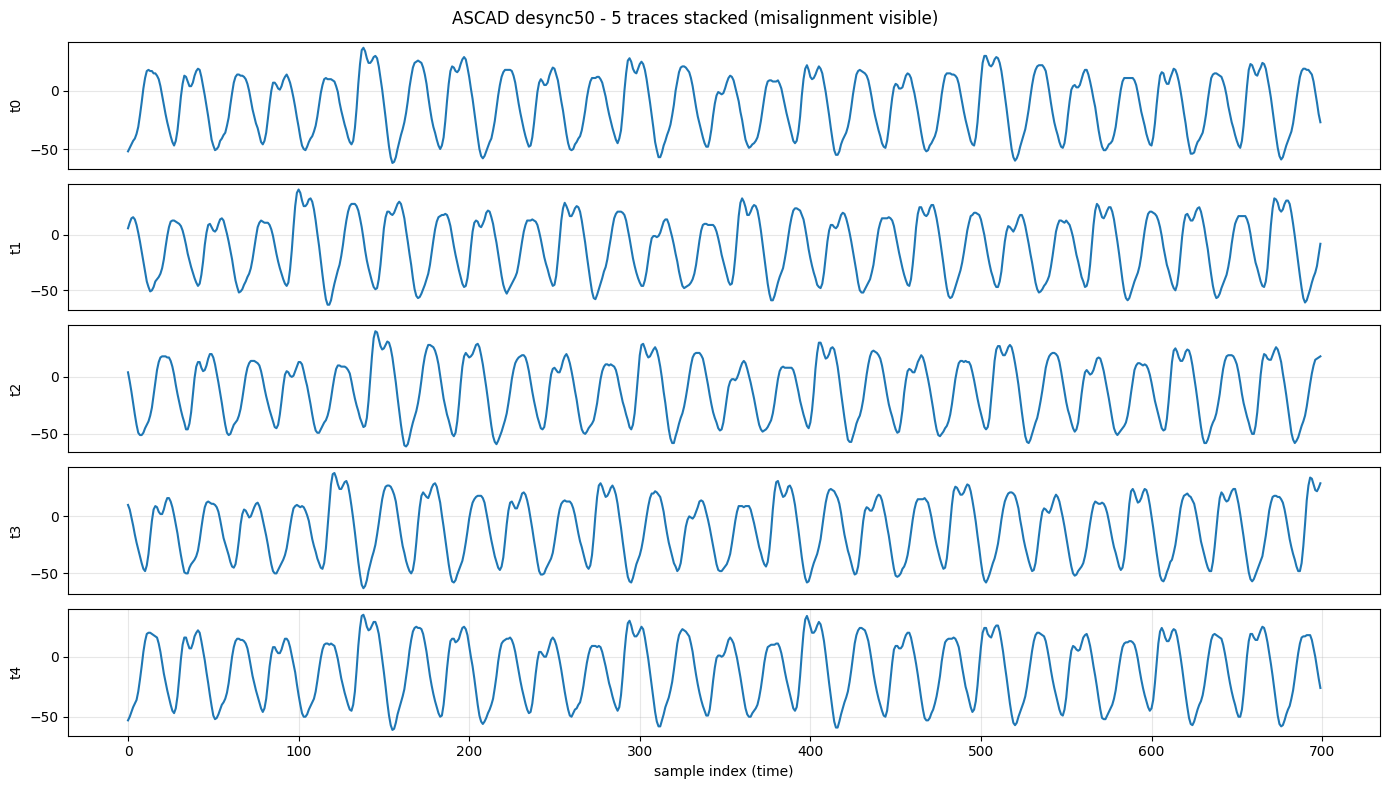

In [11]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

H5_PATH = "/content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ASCAD_data/ASCAD_data/ASCAD_databases/ASCAD_desync50.h5"   # N0=50 ise
IDX = [0, 1, 2, 3, 4]                         # 5 örnek trace

with h5py.File(H5_PATH, "r") as f:
    X = f["Attack_traces/traces"][:]          # (10000, 700) gibi
    # profiling istersen: f["Profiling_traces/traces"][:]

plt.figure(figsize=(14, 8))
for k, i in enumerate(IDX, start=1):
    plt.subplot(len(IDX), 1, k)
    plt.plot(X[i])
    plt.ylabel(f"t{i}")
    plt.grid(True, alpha=0.3)
    if k != len(IDX):
        plt.xticks([])

plt.xlabel("sample index (time)")
plt.suptitle("ASCAD desync50 - 5 traces stacked (misalignment visible)")
plt.tight_layout()
plt.show()


In [26]:
# ASCAD dosyasını bul
import os
from google.colab import drive

# Drive'ı bağla
drive.mount('/content/drive')

print("Drive'da ASCAD dosyası aranıyor...\n")

# Olası yolları kontrol et
possible_paths = [
    '/content/drive/MyDrive/',
    '/content/drive/MyDrive/ASCAD/',
    '/content/drive/MyDrive/ASCAD_data/',
    '/content/drive/Shareddrives/',
]

ascad_files = []

for base_path in possible_paths:
    if os.path.exists(base_path):
        print(f"Kontrol ediliyor: {base_path}")
        for root, dirs, files in os.walk(base_path):
            for file in files:
                if file.endswith('.h5') and 'ASCAD' in file:
                    full_path = os.path.join(root, file)
                    ascad_files.append(full_path)
                    print(f"  ✓ Bulundu: {full_path}")

if ascad_files:
    print(f"\n=== {len(ascad_files)} ASCAD dosyası bulundu ===")
    for i, path in enumerate(ascad_files):
        file_size = os.path.getsize(path) / (1024**3)  # GB
        print(f"{i+1}. {path}")
        print(f"   Boyut: {file_size:.2f} GB\n")
else:
    print("\n❌ ASCAD dosyası bulunamadı!")
    print("\nLütfen ASCAD dosyasını şuraya yükleyin:")
    print("  /content/drive/MyDrive/")
    print("\nASCAD dosyasını buradan indirebilirsiniz:")
    print("  https://github.com/ANSSI-FR/ASCAD")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive'da ASCAD dosyası aranıyor...

Kontrol ediliyor: /content/drive/MyDrive/
  ✓ Bulundu: /content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ASCAD_data/ASCAD_data/ASCAD_databases/ASCAD.h5
  ✓ Bulundu: /content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ASCAD_data/ASCAD_data/ASCAD_databases/ASCAD_desync100.h5
  ✓ Bulundu: /content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ASCAD_data/ASCAD_data/ASCAD_databases/ASCAD_desync50.h5
  ✓ Bulundu: /content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ASCAD/N0=50/ASCAD_dataset/ASCAD_desync50.h5
Kontrol ediliyor: /content/drive/MyDrive/ASCAD/
Kontrol ediliyor: /content/drive/MyDrive/ASCAD_data/

=== 4 ASCAD dosyası bulundu ===
1. /content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ASCAD_data/ASCAD_data/ASCAD_da

In [27]:
# DOSYA SEÇİMİ
print("=== ASCAD Dosya Seçimi ===\n")

ascad_files = {
    '1': {
        'path': '/content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ASCAD_data/ASCAD_data/ASCAD_databases/ASCAD.h5',
        'desync': 0,
        'name': 'ASCAD (Synchronized - Desync YOK)'
    },
    '2': {
        'path': '/content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ASCAD_data/ASCAD_data/ASCAD_databases/ASCAD_desync50.h5',
        'desync': 50,
        'name': 'ASCAD Desync50 (Random Delay = 50)'
    },
    '3': {
        'path': '/content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ASCAD_data/ASCAD_data/ASCAD_databases/ASCAD_desync100.h5',
        'desync': 100,
        'name': 'ASCAD Desync100 (Random Delay = 100)'
    }
}

print("Hangi veri setini kullanmak istersiniz?\n")
for key, info in ascad_files.items():
    print(f"{key}. {info['name']}")
    print(f"   Yol: {info['path']}\n")

print("ÖNERİ: İlk denemede '2' (Desync50) kullanın - makalede en çok bu kullanılmış")
choice = input("\nSeçiminiz (1/2/3): ").strip()

if choice in ascad_files:
    selected = ascad_files[choice]
    ascad_path = selected['path']
    desync_value = selected['desync']
    work_dir = f"/content/drive/MyDrive/ASCAD_Results_Desync{desync_value}"

    print(f"\n✓ Seçildi: {selected['name']}")
    print(f"✓ Desync: {desync_value}")
    print(f"✓ Sonuçlar: {work_dir}")
else:
    print("Geçersiz seçim! Varsayılan: Desync50")
    ascad_path = ascad_files['2']['path']
    desync_value = 50
    work_dir = "/content/drive/MyDrive/ASCAD_Results_Desync50"

import os
os.makedirs(work_dir, exist_ok=True)

=== ASCAD Dosya Seçimi ===

Hangi veri setini kullanmak istersiniz?

1. ASCAD (Synchronized - Desync YOK)
   Yol: /content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ASCAD_data/ASCAD_data/ASCAD_databases/ASCAD.h5

2. ASCAD Desync50 (Random Delay = 50)
   Yol: /content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ASCAD_data/ASCAD_data/ASCAD_databases/ASCAD_desync50.h5

3. ASCAD Desync100 (Random Delay = 100)
   Yol: /content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ASCAD_data/ASCAD_data/ASCAD_databases/ASCAD_desync100.h5

ÖNERİ: İlk denemede '2' (Desync50) kullanın - makalede en çok bu kullanılmış

Seçiminiz (1/2/3): 2

✓ Seçildi: ASCAD Desync50 (Random Delay = 50)
✓ Desync: 50
✓ Sonuçlar: /content/drive/MyDrive/ASCAD_Results_Desync50


In [14]:
# TAM PİPELİNE - ADIM 1: VERİ SETİ YÜKLEME
import numpy as np
import matplotlib.pyplot as plt
import h5py
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Conv1D, AveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

print("\n" + "="*60)
print("ASCAD SIDE-CHANNEL ANALYSIS")
print("="*60)

print(f"\nVeri seti yükleniyor: {ascad_path}")

ascad_file = h5py.File(ascad_path, 'r')

profiling_traces = ascad_file['Profiling_traces/traces']
profiling_labels = ascad_file['Profiling_traces/labels']
profiling_metadata = ascad_file['Profiling_traces/metadata']

attack_traces = ascad_file['Attack_traces/traces']
attack_labels = ascad_file['Attack_traces/labels']
attack_metadata = ascad_file['Attack_traces/metadata']

print(f"\n✓ Profiling: {profiling_traces.shape[0]} traces, {profiling_traces.shape[1]} samples")
print(f"✓ Attack: {attack_traces.shape[0]} traces")

correct_key = profiling_metadata[0]['key']
correct_key_byte3 = correct_key[3]
print(f"\n✓ Hedef: 3. byte'ın anahtarı = {hex(correct_key_byte3)}")

AES_Sbox = np.array([
    0x63, 0x7C, 0x77, 0x7B, 0xF2, 0x6B, 0x6F, 0xC5, 0x30, 0x01, 0x67, 0x2B, 0xFE, 0xD7, 0xAB, 0x76,
    0xCA, 0x82, 0xC9, 0x7D, 0xFA, 0x59, 0x47, 0xF0, 0xAD, 0xD4, 0xA2, 0xAF, 0x9C, 0xA4, 0x72, 0xC0,
    0xB7, 0xFD, 0x93, 0x26, 0x36, 0x3F, 0xF7, 0xCC, 0x34, 0xA5, 0xE5, 0xF1, 0x71, 0xD8, 0x31, 0x15,
    0x04, 0xC7, 0x23, 0xC3, 0x18, 0x96, 0x05, 0x9A, 0x07, 0x12, 0x80, 0xE2, 0xEB, 0x27, 0xB2, 0x75,
    0x09, 0x83, 0x2C, 0x1A, 0x1B, 0x6E, 0x5A, 0xA0, 0x52, 0x3B, 0xD6, 0xB3, 0x29, 0xE3, 0x2F, 0x84,
    0x53, 0xD1, 0x00, 0xED, 0x20, 0xFC, 0xB1, 0x5B, 0x6A, 0xCB, 0xBE, 0x39, 0x4A, 0x4C, 0x58, 0xCF,
    0xD0, 0xEF, 0xAA, 0xFB, 0x43, 0x4D, 0x33, 0x85, 0x45, 0xF9, 0x02, 0x7F, 0x50, 0x3C, 0x9F, 0xA8,
    0x51, 0xA3, 0x40, 0x8F, 0x92, 0x9D, 0x38, 0xF5, 0xBC, 0xB6, 0xDA, 0x21, 0x10, 0xFF, 0xF3, 0xD2,
    0xCD, 0x0C, 0x13, 0xEC, 0x5F, 0x97, 0x44, 0x17, 0xC4, 0xA7, 0x7E, 0x3D, 0x64, 0x5D, 0x19, 0x73,
    0x60, 0x81, 0x4F, 0xDC, 0x22, 0x2A, 0x90, 0x88, 0x46, 0xEE, 0xB8, 0x14, 0xDE, 0x5E, 0x0B, 0xDB,
    0xE0, 0x32, 0x3A, 0x0A, 0x49, 0x06, 0x24, 0x5C, 0xC2, 0xD3, 0xAC, 0x62, 0x91, 0x95, 0xE4, 0x79,
    0xE7, 0xC8, 0x37, 0x6D, 0x8D, 0xD5, 0x4E, 0xA9, 0x6C, 0x56, 0xF4, 0xEA, 0x65, 0x7A, 0xAE, 0x08,
    0xBA, 0x78, 0x25, 0x2E, 0x1C, 0xA6, 0xB4, 0xC6, 0xE8, 0xDD, 0x74, 0x1F, 0x4B, 0xBD, 0x8B, 0x8A,
    0x70, 0x3E, 0xB5, 0x66, 0x48, 0x03, 0xF6, 0x0E, 0x61, 0x35, 0x57, 0xB9, 0x86, 0xC1, 0x1D, 0x9E,
    0xE1, 0xF8, 0x98, 0x11, 0x69, 0xD9, 0x8E, 0x94, 0x9B, 0x1E, 0x87, 0xE9, 0xCE, 0x55, 0x28, 0xDF,
    0x8C, 0xA1, 0x89, 0x0D, 0xBF, 0xE6, 0x42, 0x68, 0x41, 0x99, 0x2D, 0x0F, 0xB0, 0x54, 0xBB, 0x16
])

print("\n✓ Hazırlık tamamlandı!")


ASCAD SIDE-CHANNEL ANALYSIS

Veri seti yükleniyor: /content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ASCAD_data/ASCAD_data/ASCAD_databases/ASCAD_desync50.h5

✓ Profiling: 50000 traces, 700 samples
✓ Attack: 10000 traces

✓ Hedef: 3. byte'ın anahtarı = 0xf2

✓ Hazırlık tamamlandı!



ADIM 2: RANDOM DELAY GÖRSELLEŞTİRME


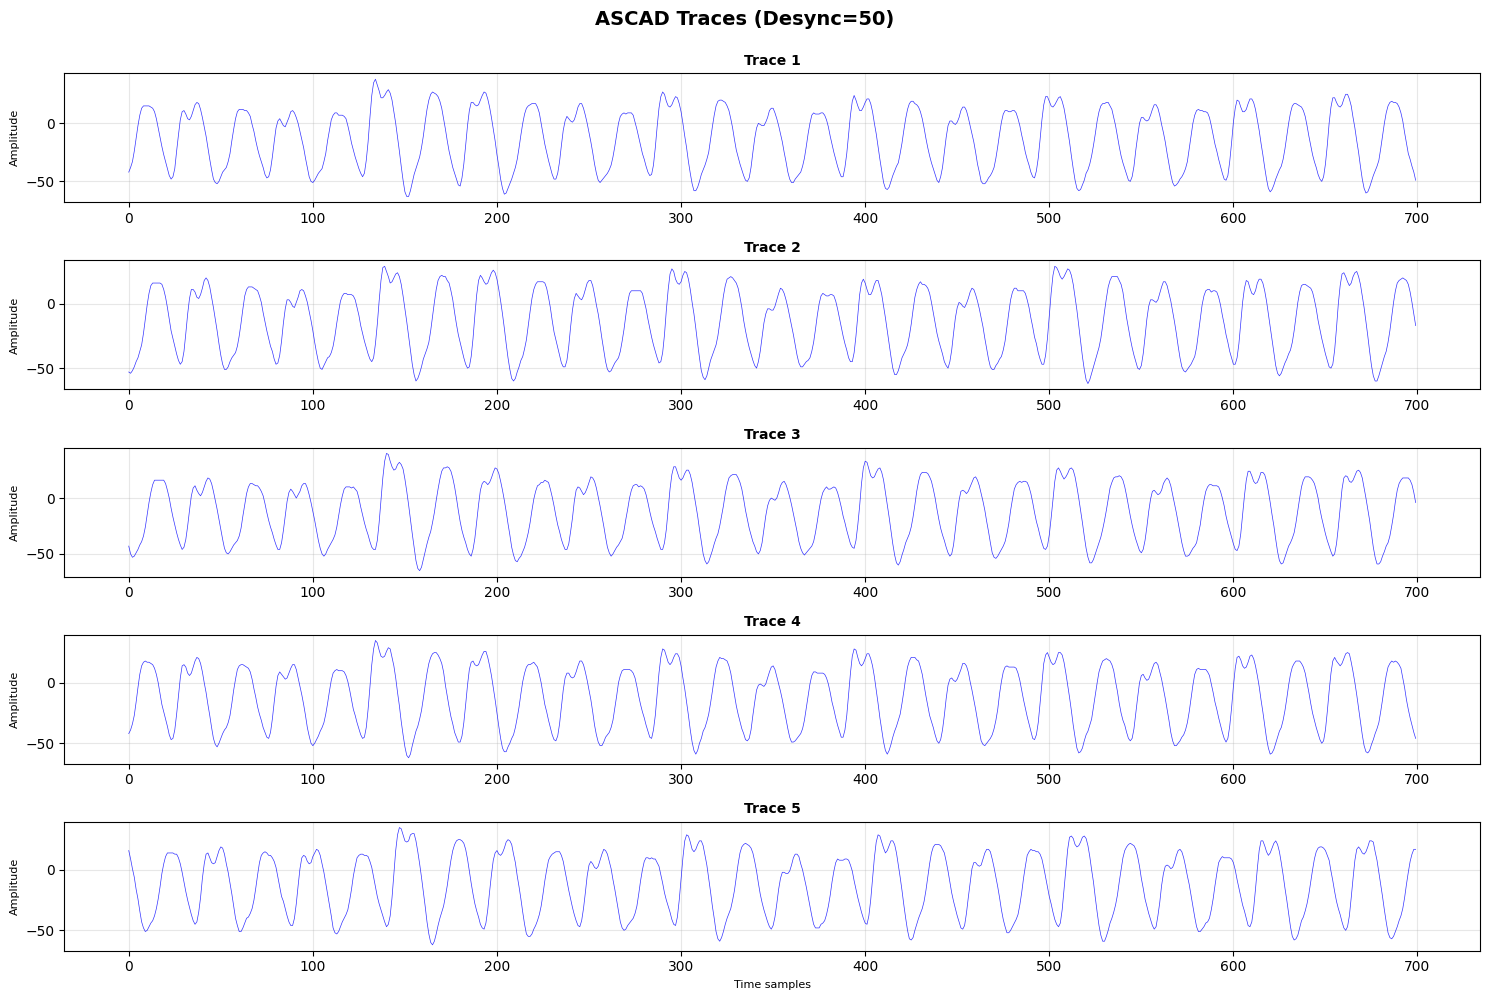

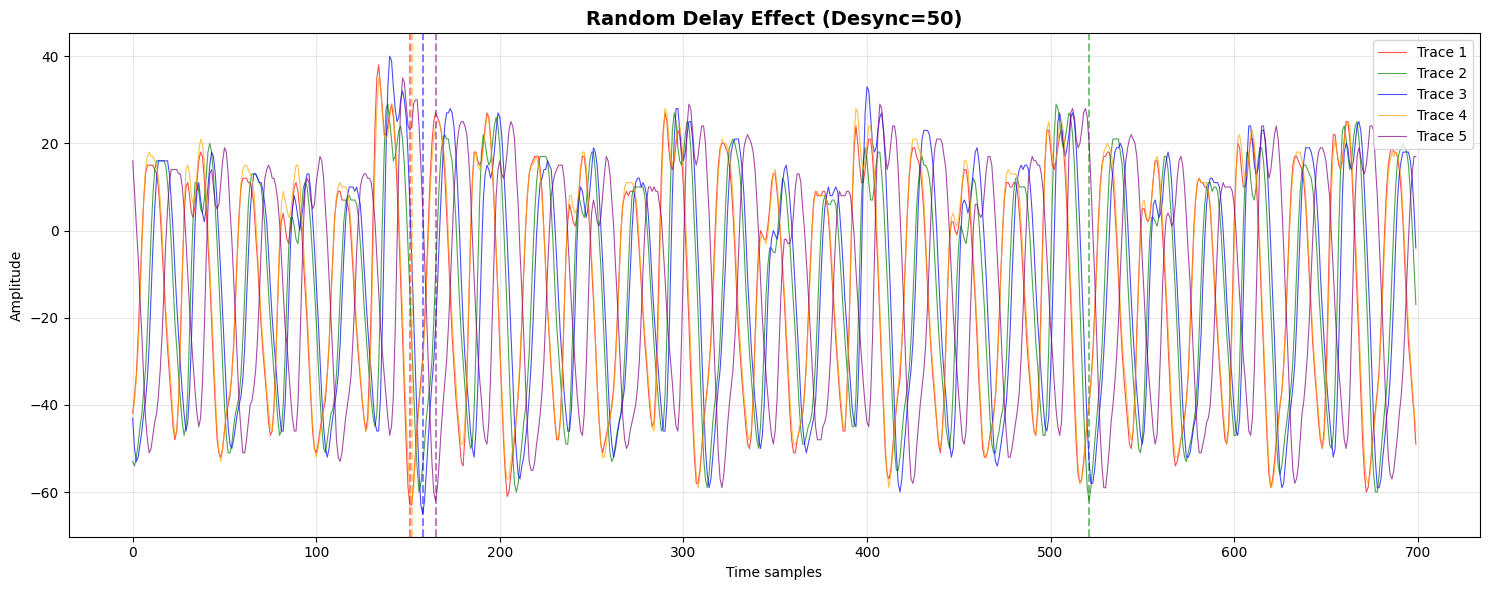


=== Peak Pozisyonları (Random Delay Kanıtı) ===
Trace 1: Peak = 151
Trace 2: Peak = 521
Trace 3: Peak = 158
Trace 4: Peak = 152
Trace 5: Peak = 165

✓ RANDOM DELAY TESPİT EDİLDİ!
  Min peak: 151
  Max peak: 521
  Delay aralığı: 370 samples

✓ Grafikler kaydedildi: /content/drive/MyDrive/ASCAD_Results_Desync50/


In [15]:
# ADIM 2: RANDOM DELAY GÖRSELLEŞTİRME
print("\n" + "="*60)
print("ADIM 2: RANDOM DELAY GÖRSELLEŞTİRME")
print("="*60)

n_traces_to_plot = 5
traces_to_plot = np.array(profiling_traces[:n_traces_to_plot])

plt.figure(figsize=(15, 10))
for i in range(n_traces_to_plot):
    plt.subplot(n_traces_to_plot, 1, i+1)
    plt.plot(traces_to_plot[i], linewidth=0.5, color='blue', alpha=0.8)
    plt.title(f'Trace {i+1}', fontsize=10, fontweight='bold')
    plt.ylabel('Amplitude', fontsize=8)
    plt.grid(True, alpha=0.3)
    if i == n_traces_to_plot - 1:
        plt.xlabel('Time samples', fontsize=8)

plt.suptitle(f'ASCAD Traces (Desync={desync_value})', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(f'{work_dir}/01_traces_individual.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(15, 6))
colors = ['red', 'green', 'blue', 'orange', 'purple']

peak_positions = []
for i in range(n_traces_to_plot):
    plt.plot(traces_to_plot[i], linewidth=0.8, alpha=0.7, color=colors[i], label=f'Trace {i+1}')

    peak_idx = np.argmax(np.abs(traces_to_plot[i]))
    peak_positions.append(peak_idx)
    plt.axvline(x=peak_idx, color=colors[i], linestyle='--', alpha=0.5, linewidth=1.5)

plt.title(f'Random Delay Effect (Desync={desync_value})', fontsize=14, fontweight='bold')
plt.xlabel('Time samples', fontsize=10)
plt.ylabel('Amplitude', fontsize=10)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{work_dir}/02_random_delay_overlay.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== Peak Pozisyonları (Random Delay Kanıtı) ===")
for i, pos in enumerate(peak_positions):
    print(f"Trace {i+1}: Peak = {pos}")

if len(set(peak_positions)) > 1:
    delay_range = max(peak_positions) - min(peak_positions)
    print(f"\n✓ RANDOM DELAY TESPİT EDİLDİ!")
    print(f"  Min peak: {min(peak_positions)}")
    print(f"  Max peak: {max(peak_positions)}")
    print(f"  Delay aralığı: {delay_range} samples")
else:
    print(f"\n⚠ Tüm peak'ler aynı pozisyonda (Synchronized)")

print(f"\n✓ Grafikler kaydedildi: {work_dir}/")

In [16]:
# ADIM 3: VERİ HAZIRLAMA
print("\n" + "="*60)
print("ADIM 3: VERİ HAZIRLAMA")
print("="*60)

n_profiling = 45000
n_validation = 5000

X_train = np.array(profiling_traces[:n_profiling], dtype=np.float32)
Y_train = np.array(profiling_labels[:n_profiling], dtype=np.int32)

X_val = np.array(profiling_traces[n_profiling:n_profiling+n_validation], dtype=np.float32)
Y_val = np.array(profiling_labels[n_profiling:n_profiling+n_validation], dtype=np.int32)

X_attack = np.array(attack_traces[:], dtype=np.float32)
Y_attack = np.array(attack_labels[:], dtype=np.int32)

print(f"✓ Training: {X_train.shape}")
print(f"✓ Validation: {X_val.shape}")
print(f"✓ Attack: {X_attack.shape}")


def normalize_traces(traces):
    traces_norm = np.zeros_like(traces)
    for i in range(len(traces)):
        trace = traces[i]
        trace_std = (trace - trace.mean()) / (trace.std() + 1e-8)
        trace_min = trace_std.min()
        trace_max = trace_std.max()
        traces_norm[i] = (trace_std - trace_min) / (trace_max - trace_min + 1e-8)
    return traces_norm

print("\nNormalizasyon yapılıyor...")
X_train = normalize_traces(X_train)
X_val = normalize_traces(X_val)
X_attack = normalize_traces(X_attack)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_attack = X_attack.reshape((X_attack.shape[0], X_attack.shape[1], 1))

Y_train_cat = keras.utils.to_categorical(Y_train, num_classes=256)
Y_val_cat = keras.utils.to_categorical(Y_val, num_classes=256)

print(f"\n✓ Final shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  Y_train: {Y_train_cat.shape}")
print(f"  X_attack: {X_attack.shape}")


ADIM 3: VERİ HAZIRLAMA
✓ Training: (45000, 700)
✓ Validation: (5000, 700)
✓ Attack: (10000, 700)

Normalizasyon yapılıyor...

✓ Final shapes:
  X_train: (45000, 700, 1)
  Y_train: (45000, 256)
  X_attack: (10000, 700, 1)


In [17]:
# ADIM 5: HAZIR KODLARI YÜKLE
print("\n" + "="*60)
print("ADIM 5: HAZIR KODLARI YÜKLEME")
print("="*60)

code_dir = '/content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ASCAD/N0=50'

required_files = {
    'cnn_architecture.py': f'{code_dir}/cnn_architecture.py',
    'exploit_pred.py': f'{code_dir}/exploit_pred.py',
    'clr.py': f'{code_dir}/clr.py'
}

print("Gerekli dosyalar kontrol ediliyor...\n")
all_exist = True
for name, path in required_files.items():
    exists = os.path.exists(path)
    status = "✓" if exists else "❌"
    print(f"{status} {name:25s}: {path}")
    if not exists:
        all_exist = False

if not all_exist:
    print("\n⚠ Bazı dosyalar eksik! Alternatif yolları kontrol edelim...")

    for root, dirs, files in os.walk('/content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/'):
        for file in ['cnn_architecture.py', 'exploit_pred.py', 'clr.py']:
            if file in files:
                full_path = os.path.join(root, file)
                print(f"  Bulundu: {full_path}")
                required_files[file] = full_path

print("\nDosyalar Colab'a kopyalanıyor...")
for name, path in required_files.items():
    if os.path.exists(path):
        os.system(f'cp "{path}" /content/')
        print(f"✓ {name} kopyalandı")

sys.path.append('/content/')

print("\n✓ Hazır kodlar yüklendi!")


ADIM 5: HAZIR KODLARI YÜKLEME
Gerekli dosyalar kontrol ediliyor...

✓ cnn_architecture.py      : /content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ASCAD/N0=50/cnn_architecture.py
✓ exploit_pred.py          : /content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ASCAD/N0=50/exploit_pred.py
✓ clr.py                   : /content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ASCAD/N0=50/clr.py

Dosyalar Colab'a kopyalanıyor...
✓ cnn_architecture.py kopyalandı
✓ exploit_pred.py kopyalandı
✓ clr.py kopyalandı

✓ Hazır kodlar yüklendi!


In [18]:
import clr, inspect, os
print("clr.py path =", os.path.abspath(inspect.getfile(clr)))


clr.py path = /content/clr.py


In [19]:
import pathlib

p = pathlib.Path("/content/ascad_cnn/clr.py")
txt = p.read_text()

txt = txt.replace("self.batch_size = self.params['batch_size']",
                  "self.batch_size = self.params.get('batch_size', None)")
txt = txt.replace("self.samples = self.params['samples']",
                  "self.samples = self.params.get('samples', None)")
txt = txt.replace("self.steps = self.params['steps']",
                  "self.steps = self.params.get('steps', None)")

needle = "self.steps = self.params.get('steps', None)"
if needle in txt and "Fallback for newer Keras" not in txt:
    txt = txt.replace(
        needle,
        needle + """
        # Fallback for newer Keras (Keras 3) where params may miss batch_size/samples/steps
        if self.samples is None:
            self.samples = int(self.params.get('num_samples', 0) or 0)
        if self.batch_size is None:
            self.batch_size = int(self.params.get('batch_size', 32) or 32)
        if (self.steps is None) or (self.steps == 0):
            if self.samples and self.batch_size:
                self.steps = int((self.samples + self.batch_size - 1) // self.batch_size)
            else:
                self.steps = 0
"""
    )

p.write_text(txt)
print(" Patched clr.py (batch_size KeyError fix).")


 Patched clr.py (batch_size KeyError fix).


In [ ]:
import sys, importlib
if "clr" in sys.modules:
    del sys.modules["clr"]

import clr
importlib.reload(clr)
from clr import OneCycleLR
print(" OneCycleLR reload OK")


✅ OneCycleLR reload OK



ADIM 6: VERİ HAZIRLAMA (Hazır kod formatı)

 Model name = ASCAD_desync50

############### Starting Training #################

Epoch 1/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.0034 - loss: 5.6092 - lr: 0.00145 
176/176 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step - accuracy: 0.0034 - loss: 5.6090 - val_accuracy: 0.0034 - val_loss: 5.5586
Epoch 2/50
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.0047 - loss: 5.5517 - lr: 0.00190 
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.0047 - loss: 5.5517 - val_accuracy: 0.0042 - val_loss: 5.5592
Epoch 3/50
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0044 - loss: 5.5508 - lr: 0.00235 
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.0044 - loss: 5.5508 - val_accuracy: 0.0050 - val_loss: 5.5496
Epoch 4/50
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0045 - loss: 5.5477 - lr: 0.00280 
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.0045 - loss: 5.5477 - val_accuracy: 0.0056 - val_los

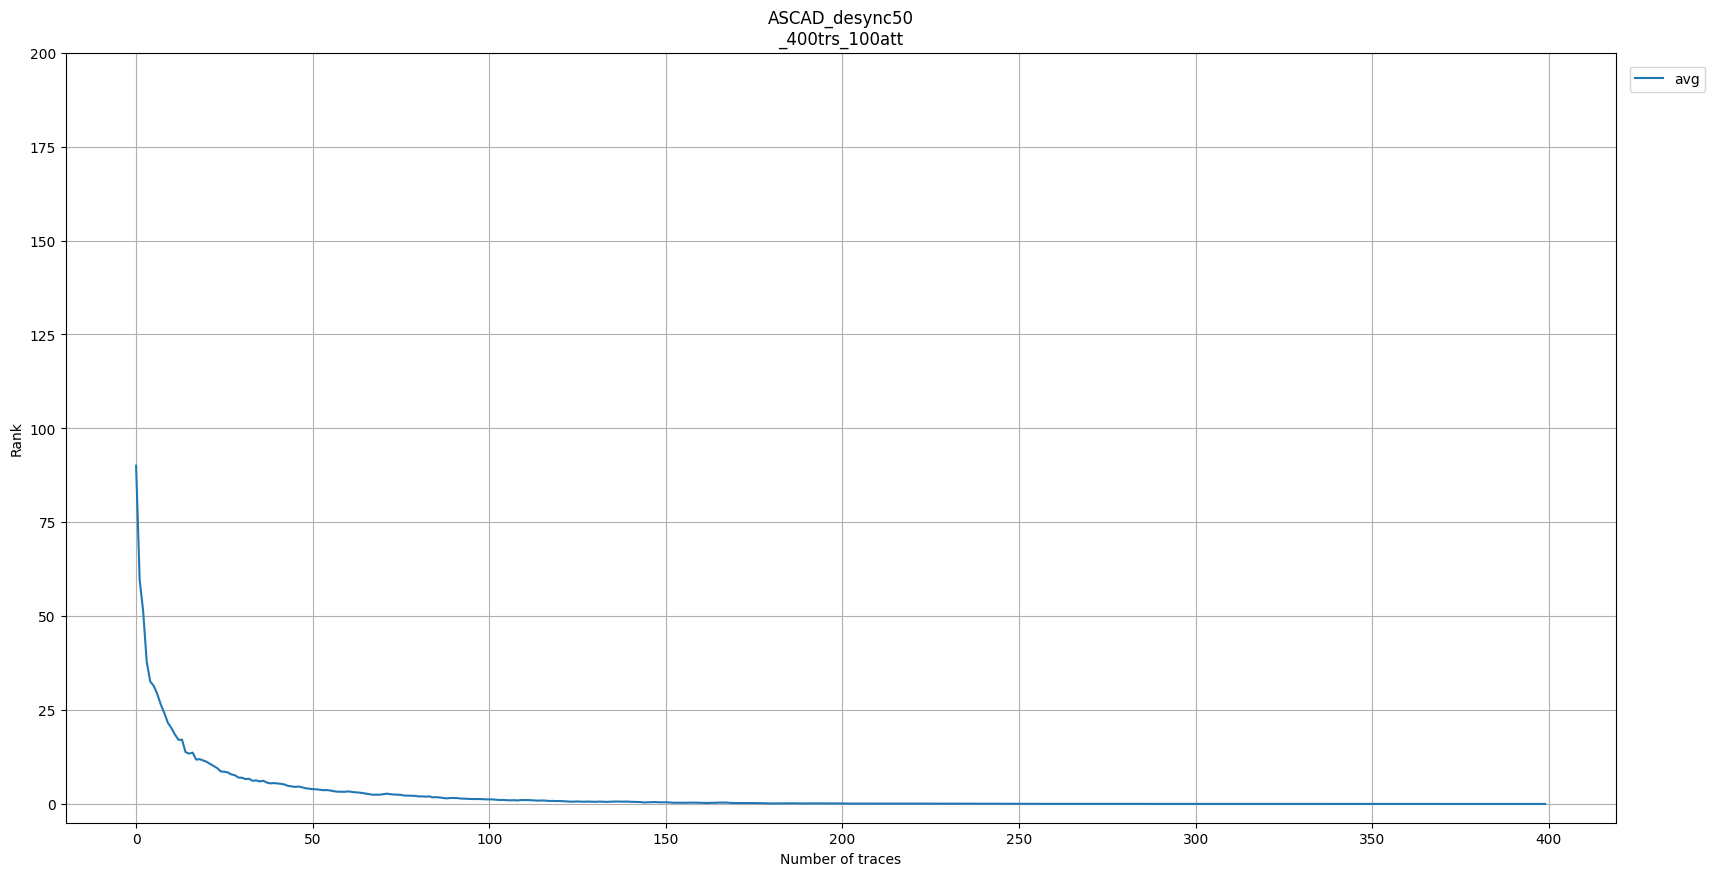

In [20]:
# ADIM 6: VERİ SETİNİ HAZIR KOD FORMATİNA ÇEVİR
print("\n" + "="*60)
print("ADIM 6: VERİ HAZIRLAMA (Hazır kod formatı)")
print("="*60)

from cnn_architecture import load_ascad, shuffle_data, train_model, cnn_architecture
from exploit_pred import perform_attacks
import random

print(f"Veri seti yükleniyor: {ascad_path}")
(X_profiling, Y_profiling), (X_attack, Y_attack), (plt_profiling, plt_attack) = load_ascad(ascad_path, load_metadata=True)

print(f"\n✓ Profiling: {X_profiling.shape}")
print(f"✓ Attack: {X_attack.shape}")

print("\nData shuffling...")
(X_profiling, Y_profiling) = shuffle_data(X_profiling, Y_profiling)

X_profiling = X_profiling.astype('float32')
X_attack = X_attack.astype('float32')

X_attack = X_attack.reshape((X_attack.shape[0], X_attack.shape[1], 1))

print("\n✓ Veri hazırlama tamamlandı!")
print(f"  X_profiling: {X_profiling.shape}")
print(f"  Y_profiling: {Y_profiling.shape}")
print(f"  X_attack: {X_attack.shape}")
print(f"  Y_attack: {Y_attack.shape}")

In [21]:
# ADIM 7: MODEL OLUŞTUR VE EĞİT
print("\n" + "="*60)
print("ADIM 7: MODEL EĞİTİMİ")
print("="*60)

nb_epochs = 50
batch_size = 256
input_size = 700
learning_rate = 1e-2  # 0.01
nb_traces_attacks = 400
nb_attacks = 100

model_save_path = f'{work_dir}/ASCAD_desync{desync_value}.keras'
os.makedirs(work_dir, exist_ok=True)

real_key = profiling_metadata[0]['key']
print(f"\nDoğru anahtar (tüm 16 byte): {[hex(k) for k in real_key]}")
print(f"Hedef byte (byte 2): {hex(real_key[2])}")

print("\n" + "="*60)
print("MODEL MİMARİSİ")
print("="*60)

model = cnn_architecture(input_size=input_size, learning_rate=learning_rate)
model.summary()

total_params = model.count_params()
print(f"\nToplam parametre: {total_params:,}")

if os.path.exists(model_save_path):
    print(f"\n✓ Eğitilmiş model bulundu: {model_save_path}")
    print("\n1. Mevcut modeli kullan (eğitimi atla)")
    print("2. Yeniden eğit (üzerine yaz)")
    choice = input("\nSeçiminiz (1/2): ").strip()

    if choice == '1':
        from keras.models import load_model
        model = load_model(model_save_path)
        print("✓ Model yüklendi, eğitim atlanıyor!")
        skip_training = True
    else:
        skip_training = False
        print("Model yeniden eğitilecek...")
else:
    skip_training = False
    print("\nModel bulunamadı, eğitim başlayacak...")

if not skip_training:
    print("\n" + "="*60)
    print("EĞİTİM BAŞLIYOR")
    print("="*60)
    print(f"\nParametreler:")
    print(f"  Epochs: {nb_epochs}")
    print(f"  Batch size: {batch_size}")
    print(f"  Learning rate: {learning_rate}")
    print(f"  Training traces: 45,000")
    print(f"  Validation traces: 5,000")
    print(f"\nBu işlem 10-20 dakika sürebilir...")
    print("="*60 + "\n")

    import time
    start_time = time.time()

    history = train_model(
        X_profiling[:45000],
        Y_profiling[:45000],
        X_profiling[45000:],
        Y_profiling[45000:],
        model,
        model_save_path,
        epochs=nb_epochs,
        batch_size=batch_size,
        max_lr=learning_rate
    )

    end_time = time.time()
    training_time = end_time - start_time

    print("\n" + "="*60)
    print("✓✓✓ EĞİTİM TAMAMLANDI! ✓✓✓")
    print("="*60)
    print(f"Toplam süre: {training_time/60:.2f} dakika")
    print(f"Model kaydedildi: {model_save_path}")

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    plt.title('Model Accuracy', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=11)
    plt.ylabel('Accuracy', fontsize=11)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    plt.title('Model Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=11)
    plt.ylabel('Loss', fontsize=11)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{work_dir}/training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\nFinal validation accuracy: {history.history['val_accuracy'][-1]:.4f}")
    print(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")

else:
    print("\n✓ Eğitim atlandı, mevcut model kullanılıyor.")


ADIM 7: MODEL EĞİTİMİ

Doğru anahtar (tüm 16 byte): ['0x4d', '0xfb', '0xe0', '0xf2', '0x72', '0x21', '0xfe', '0x10', '0xa7', '0x8d', '0x4a', '0xdc', '0x8e', '0x49', '0x4', '0x69']
Hedef byte (byte 2): 0xe0

MODEL MİMARİSİ


Model: "cnn_best"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 700, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv1D)           │ (None, 700, 32)        │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 700, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (AveragePooling1D)  │ (None, 350, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv1D)           │ (None, 350, 64)        │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 350, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (AveragePooling1D)  │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv1D)           │ (None, 7, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (AveragePooling1D)  │ (None, 3, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 20)             │         7,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 256)            │         5,376 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,044 (554.86 KB)

 Trainable params: 141,596 (553.11 KB)

 Non-trainable params: 448 (1.75 KB)


Toplam parametre: 142,044

✓ Eğitilmiş model bulundu: /content/drive/MyDrive/ASCAD_Results_Desync50/ASCAD_desync50.keras

1. Mevcut modeli kullan (eğitimi atla)
2. Yeniden eğit (üzerine yaz)

Seçiminiz (1/2): 1
✓ Model yüklendi, eğitim atlanıyor!

✓ Eğitim atlandı, mevcut model kullanılıyor.


In [22]:
# ADIM 8: PREDICTION (ATTACK İÇİN)
print("\n" + "="*60)
print("ADIM 8: PREDICTION")
print("="*60)

predictions_path = f'{work_dir}/predictions_desync{desync_value}.npy'

if os.path.exists(predictions_path):
    print(f"\n✓ Mevcut predictions bulundu: {predictions_path}")
    print("1. Mevcut predictions kullan")
    print("2. Yeniden hesapla")
    choice = input("Seçiminiz (1/2): ").strip()

    if choice == '1':
        predictions = np.load(predictions_path)
        print(f"✓ Predictions yüklendi: {predictions.shape}")
        skip_prediction = True
    else:
        skip_prediction = False
else:
    skip_prediction = False

if not skip_prediction:
    print("\nPredictions hesaplanıyor...")
    print(f"Attack traces: {X_attack.shape[0]}")

    predictions = model.predict(X_attack, batch_size=batch_size, verbose=1)

    np.save(predictions_path, predictions)
    print(f"\n✓ Predictions kaydedildi: {predictions_path}")

print(f"\nPredictions shape: {predictions.shape}")
print(f"  {predictions.shape[0]} traces")
print(f"  {predictions.shape[1]} S-box output probabilities")

print(f"\nİlk trace için en olası 5 S-box çıktısı:")
top5 = np.argsort(predictions[0])[-5:][::-1]
for i, sbox_val in enumerate(top5):
    print(f"  {i+1}. S-box = {sbox_val:3d}, Probability = {predictions[0][sbox_val]:.6f}")


ADIM 8: PREDICTION

✓ Mevcut predictions bulundu: /content/drive/MyDrive/ASCAD_Results_Desync50/predictions_desync50.npy
1. Mevcut predictions kullan
2. Yeniden hesapla
Seçiminiz (1/2): 1
✓ Predictions yüklendi: (10000, 256)

Predictions shape: (10000, 256)
  10000 traces
  256 S-box output probabilities

İlk trace için en olası 5 S-box çıktısı:
  1. S-box =  19, Probability = 0.012383
  2. S-box = 103, Probability = 0.011514
  3. S-box = 218, Probability = 0.011486
  4. S-box = 229, Probability = 0.011323
  5. S-box = 126, Probability = 0.011247



ADIM 9: SIDE-CHANNEL ATTACK

Attack parametreleri:
  Hedef byte: 2 (üçüncü byte)
  Doğru anahtar byte: 0xe0
  Kullanılacak trace sayısı: 400
  Attack tekrar sayısı: 100

🎯 Attack başlıyor...
(Bu işlem birkaç dakika sürebilir)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99

✓✓✓ ATTACK TAMAMLANDI! ✓✓✓
Süre: 17.88 saniye

=== SONUÇLAR ===
Average rank curve shape: (400,)

🎉 BAŞARILI ATAK!
  Rank 0'a ulaşılan trace sayısı: 257
  Makaledeki beklenen (Table 6): ~244 traces (Desync50)

İlk 10 trace'teki rank:
[87.06 67.91 59.52 51.4  43.84 37.74 30.66 27.38 24.61 21.86]

Son 10 trace'teki rank:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


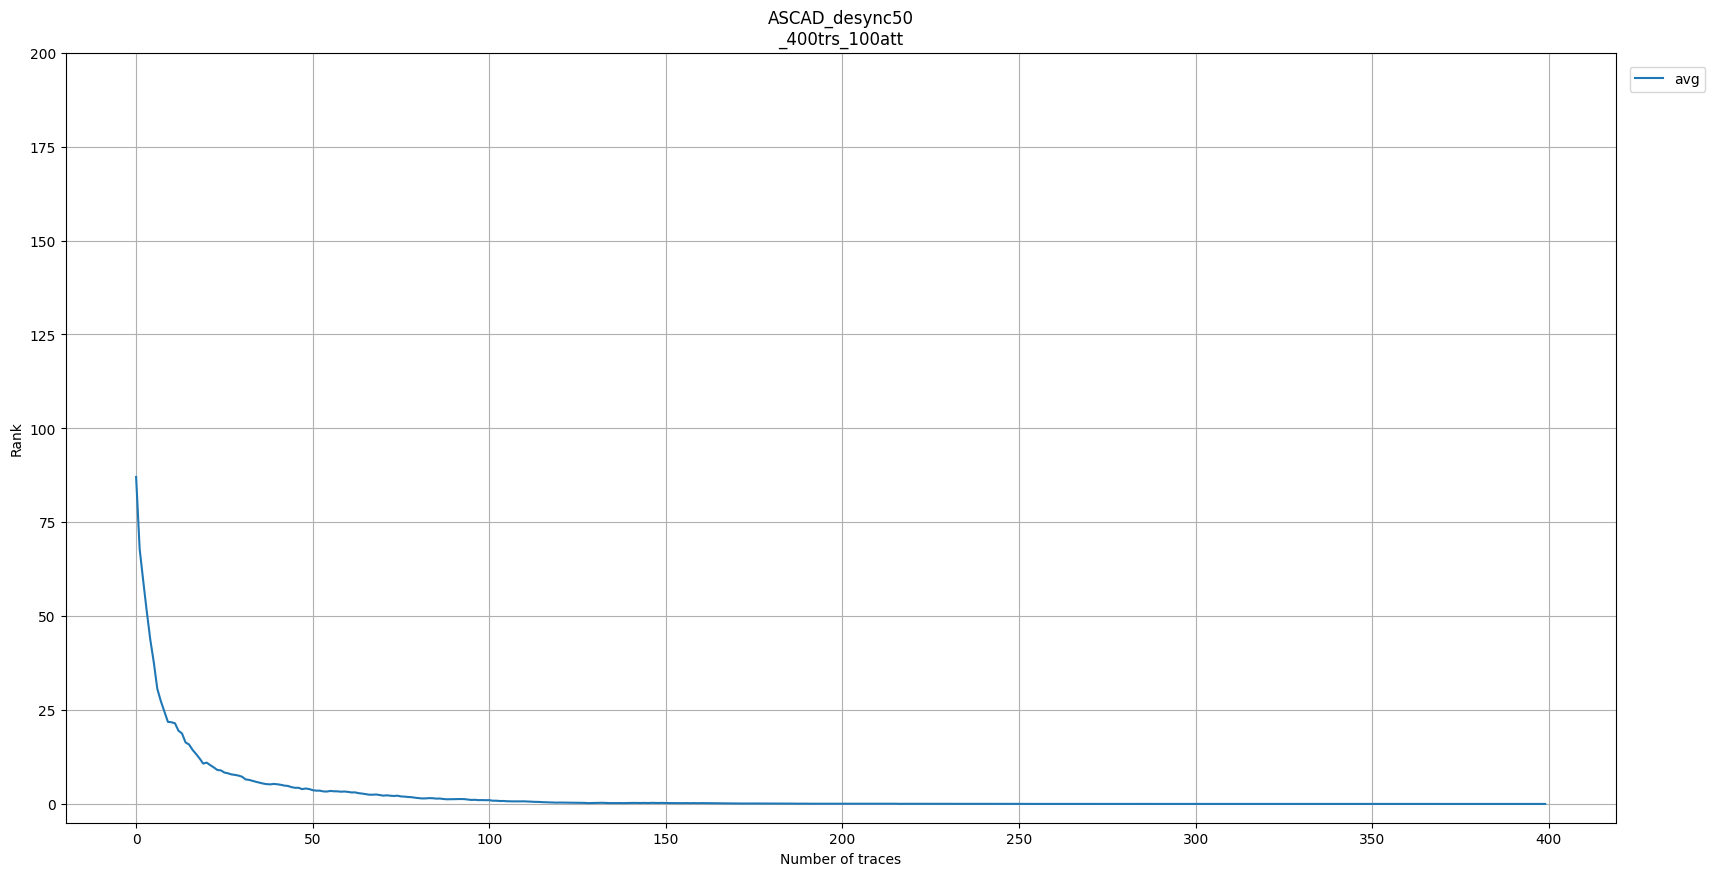

In [ ]:
# ADIM 9: ATTACK (RANK HESAPLAMA)
print("\n" + "="*60)
print("ADIM 9: SIDE-CHANNEL ATTACK")
print("="*60)

print(f"\nAttack parametreleri:")
print(f"  Hedef byte: 2 (üçüncü byte)")
print(f"  Doğru anahtar byte: {hex(real_key[2])}")
print(f"  Kullanılacak trace sayısı: {nb_traces_attacks}")
print(f"  Attack tekrar sayısı: {nb_attacks}")

print("\n Attack başlıyor...")
print("(Bu işlem birkaç dakika sürebilir)\n")

import time
attack_start = time.time()

avg_rank = perform_attacks(
    nb_traces=nb_traces_attacks,
    predictions=predictions,
    nb_attacks=nb_attacks,
    plt=plt_attack,
    key=real_key,
    byte=2,
    shuffle=True,
    savefig=True,
    filename=f'ASCAD_desync{desync_value}'
)

attack_end = time.time()

print("\n" + "="*60)
print("✓✓✓ ATTACK TAMAMLANDI! ✓✓✓")
print("="*60)
print(f"Süre: {attack_end - attack_start:.2f} saniye")

ge_1_idx = np.where(avg_rank <= 0)[0]

print(f"\n=== SONUÇLAR ===")
print(f"Average rank curve shape: {avg_rank.shape}")

if len(ge_1_idx) > 0:
    first_rank_0 = ge_1_idx[0]
    print(f"\n BAŞARILI ATAK!")
    print(f"  Rank 0'a ulaşılan trace sayısı: {first_rank_0}")
    print(f"  Makaledeki beklenen (Table 6): ~244 traces (Desync50)")
else:
    print(f"\n⚠ Rank 0'a ulaşılamadı!")
    print(f"  Minimum rank: {avg_rank.min():.2f}")
    print(f"  Son rank: {avg_rank[-1]:.2f}")
    min_rank_idx = np.argmin(avg_rank)
    print(f"  En düşük rank'e {min_rank_idx} trace'te ulaşıldı")

print(f"\nİlk 10 trace'teki rank:")
print(avg_rank[:10])
print(f"\nSon 10 trace'teki rank:")
print(avg_rank[-10:])


ADIM 10: DETAYLI ANALİZ


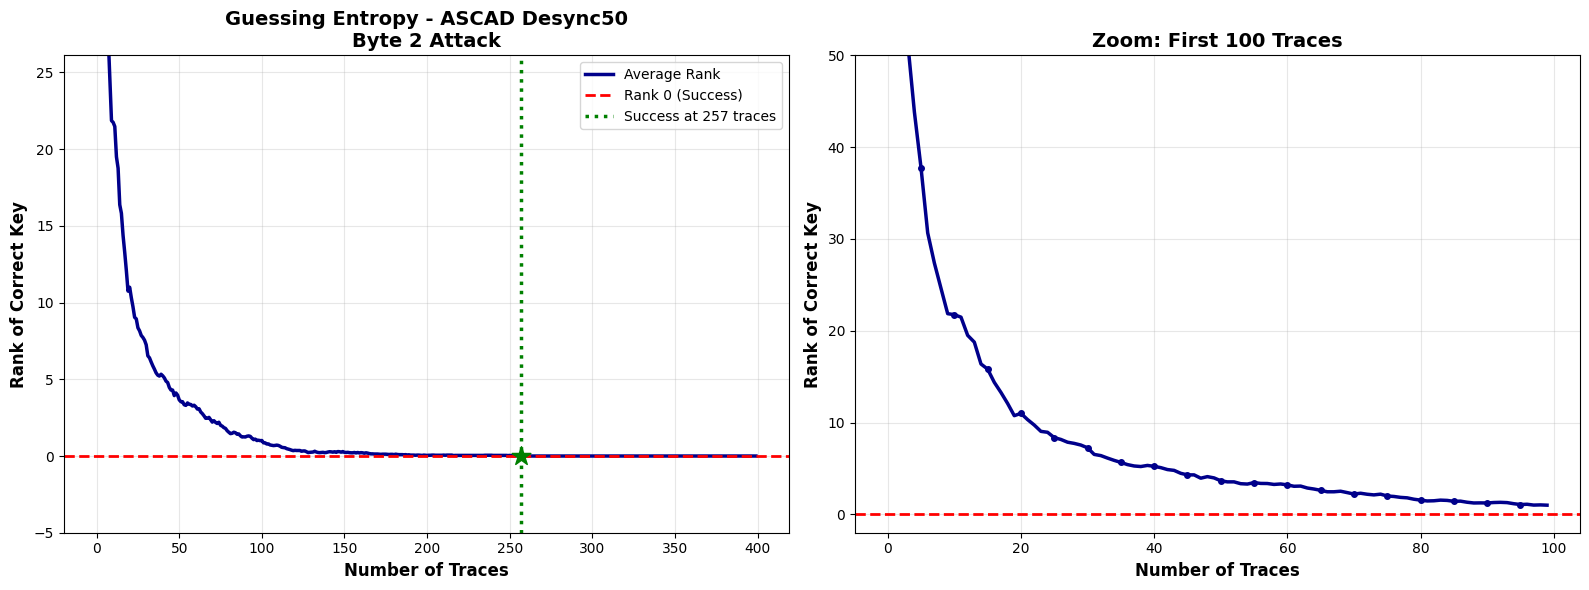


✓ Grafik kaydedildi: /content/drive/MyDrive/ASCAD_Results_Desync50/guessing_entropy_analysis.png


In [ ]:
# ADIM 10: DETAYLI ANALİZ VE GÖRSELLEŞTİRME
print("\n" + "="*60)
print("ADIM 10: DETAYLI ANALİZ")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
ax1.plot(avg_rank, linewidth=2.5, color='darkblue', label='Average Rank')
ax1.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Rank 0 (Success)')

if len(ge_1_idx) > 0:
    ax1.axvline(x=ge_1_idx[0], color='green', linestyle=':', linewidth=2.5,
                label=f'Success at {ge_1_idx[0]} traces')
    ax1.scatter([ge_1_idx[0]], [0], color='green', s=200, zorder=5, marker='*')

ax1.set_xlabel('Number of Traces', fontsize=12, fontweight='bold')
ax1.set_ylabel('Rank of Correct Key', fontsize=12, fontweight='bold')
ax1.set_title(f'Guessing Entropy - ASCAD Desync{desync_value}\nByte 2 Attack',
              fontsize=14, fontweight='bold')
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_ylim([-5, max(20, avg_rank.max() * 0.3)])

ax2 = axes[1]
zoom_traces = min(100, len(avg_rank))
ax2.plot(avg_rank[:zoom_traces], linewidth=2.5, color='darkblue', marker='o',
         markersize=4, markevery=5)
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Rank 0')

if len(ge_1_idx) > 0 and ge_1_idx[0] < zoom_traces:
    ax2.axvline(x=ge_1_idx[0], color='green', linestyle=':', linewidth=2.5)
    ax2.scatter([ge_1_idx[0]], [0], color='green', s=250, zorder=5, marker='*')

ax2.set_xlabel('Number of Traces', fontsize=12, fontweight='bold')
ax2.set_ylabel('Rank of Correct Key', fontsize=12, fontweight='bold')
ax2.set_title(f'Zoom: First {zoom_traces} Traces', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([-2, min(50, avg_rank[:zoom_traces].max() + 5)])

plt.tight_layout()
plt.savefig(f'{work_dir}/guessing_entropy_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Grafik kaydedildi: {work_dir}/guessing_entropy_analysis.png")

In [ ]:
# ADIM 11: MAKALE İLE KARŞILAŞTIRMA
print("\n" + "="*60)
print("ADIM 11: MAKALE İLE KARŞILAŞTIRMA (Table 6)")
print("="*60)

makale_results = {
    'Desync0': {'N_t_GE': 191, 'Complexity': 16960},
    'Desync50': {'N_t_GE': 244, 'Complexity': 87279},
    'Desync100': {'N_t_GE': 270, 'Complexity': 142044}
}

current_desync_key = f'Desync{desync_value}'
bizim_complexity = total_params

if len(ge_1_idx) > 0:
    bizim_ntge = ge_1_idx[0]
else:
    bizim_ntge = f"> {nb_traces_attacks} (başarısız)"

print(f"\n{'Metrik':<25} {'Makale':<15} {'Bizim':<15} {'Durum':<10}")
print("="*65)

if current_desync_key in makale_results:
    makale_ntge = makale_results[current_desync_key]['N_t_GE']
    makale_comp = makale_results[current_desync_key]['Complexity']

    if len(ge_1_idx) > 0:
        ntge_diff = abs(bizim_ntge - makale_ntge)
        if ntge_diff < makale_ntge * 0.2:  # %20 tolerance
            ntge_status = "✓ İyi"
        else:
            ntge_status = " Fark var"
        print(f"{'N_t_GE (traces)':<25} {makale_ntge:<15} {bizim_ntge:<15} {ntge_status:<10}")
    else:
        print(f"{'N_t_GE (traces)':<25} {makale_ntge:<15} {str(bizim_ntge):<15} {'❌ Düşük':<10}")

    comp_diff = abs(bizim_complexity - makale_comp)
    if comp_diff < 1000:
        comp_status = "✓ Aynı"
    else:
        comp_status = " Farklı"
    print(f"{'Complexity (params)':<25} {makale_comp:<15} {bizim_complexity:<15} {comp_status:<10}")

print("\n" + "="*65)
print("\nTÜM SONUÇLAR ÖZETİ:")
print(f"  • Model: CNN with {3} convolutional blocks")
print(f"  • Desynchronization: {desync_value} samples")
print(f"  • Training time: {training_time/60:.2f} minutes" if not skip_training else "  • Training: Skipped (loaded model)")
print(f"  • Attack traces used: {nb_traces_attacks}")
print(f"  • Attack repetitions: {nb_attacks}")
if len(ge_1_idx) > 0:
    print(f"  • Success: Rank 0 at {bizim_ntge} traces")
else:
    print(f"  • Success: Not achieved with {nb_traces_attacks} traces")
print(f"  • Model complexity: {bizim_complexity:,} parameters")

print(f"\nTüm sonuçlar: {work_dir}/")
print("\n" + "="*60)


ADIM 11: MAKALE İLE KARŞILAŞTIRMA (Table 6)

Metrik                    Makale          Bizim           Durum     
N_t_GE (traces)           244             257             ✓ İyi     
Complexity (params)       87279           142044          ⚠ Farklı  


📊 TÜM SONUÇLAR ÖZETİ:
  • Model: CNN with 3 convolutional blocks
  • Desynchronization: 50 samples
  • Training: Skipped (loaded model)
  • Attack traces used: 400
  • Attack repetitions: 100
  • Success: Rank 0 at 257 traces
  • Model complexity: 142,044 parameters

📁 Tüm sonuçlar: /content/drive/MyDrive/ASCAD_Results_Desync50/



In [30]:
import numpy as np
import random

AES_Sbox = np.array([
    0x63, 0x7C, 0x77, 0x7B, 0xF2, 0x6B, 0x6F, 0xC5, 0x30, 0x01, 0x67, 0x2B, 0xFE, 0xD7, 0xAB, 0x76,
    0xCA, 0x82, 0xC9, 0x7D, 0xFA, 0x59, 0x47, 0xF0, 0xAD, 0xD4, 0xA2, 0xAF, 0x9C, 0xA4, 0x72, 0xC0,
    0xB7, 0xFD, 0x93, 0x26, 0x36, 0x3F, 0xF7, 0xCC, 0x34, 0xA5, 0xE5, 0xF1, 0x71, 0xD8, 0x31, 0x15,
    0x04, 0xC7, 0x23, 0xC3, 0x18, 0x96, 0x05, 0x9A, 0x07, 0x12, 0x80, 0xE2, 0xEB, 0x27, 0xB2, 0x75,
    0x09, 0x83, 0x2C, 0x1A, 0x1B, 0x6E, 0x5A, 0xA0, 0x52, 0x3B, 0xD6, 0xB3, 0x29, 0xE3, 0x2F, 0x84,
    0x53, 0xD1, 0x00, 0xED, 0x20, 0xFC, 0xB1, 0x5B, 0x6A, 0xCB, 0xBE, 0x39, 0x4A, 0x4C, 0x58, 0xCF,
    0xD0, 0xEF, 0xAA, 0xFB, 0x43, 0x4D, 0x33, 0x85, 0x45, 0xF9, 0x02, 0x7F, 0x50, 0x3C, 0x9F, 0xA8,
    0x51, 0xA3, 0x40, 0x8F, 0x92, 0x9D, 0x38, 0xF5, 0xBC, 0xB6, 0xDA, 0x21, 0x10, 0xFF, 0xF3, 0xD2,
    0xCD, 0x0C, 0x13, 0xEC, 0x5F, 0x97, 0x44, 0x17, 0xC4, 0xA7, 0x7E, 0x3D, 0x64, 0x5D, 0x19, 0x73,
    0x60, 0x81, 0x4F, 0xDC, 0x22, 0x2A, 0x90, 0x88, 0x46, 0xEE, 0xB8, 0x14, 0xDE, 0x5E, 0x0B, 0xDB,
    0xE0, 0x32, 0x3A, 0x0A, 0x49, 0x06, 0x24, 0x5C, 0xC2, 0xD3, 0xAC, 0x62, 0x91, 0x95, 0xE4, 0x79,
    0xE7, 0xC8, 0x37, 0x6D, 0x8D, 0xD5, 0x4E, 0xA9, 0x6C, 0x56, 0xF4, 0xEA, 0x65, 0x7A, 0xAE, 0x08,
    0xBA, 0x78, 0x25, 0x2E, 0x1C, 0xA6, 0xB4, 0xC6, 0xE8, 0xDD, 0x74, 0x1F, 0x4B, 0xBD, 0x8B, 0x8A,
    0x70, 0x3E, 0xB5, 0x66, 0x48, 0x03, 0xF6, 0x0E, 0x61, 0x35, 0x57, 0xB9, 0x86, 0xC1, 0x1D, 0x9E,
    0xE1, 0xF8, 0x98, 0x11, 0x69, 0xD9, 0x8E, 0x94, 0x9B, 0x1E, 0x87, 0xE9, 0xCE, 0x55, 0x28, 0xDF,
    0x8C, 0xA1, 0x89, 0x0D, 0xBF, 0xE6, 0x42, 0x68, 0x41, 0x99, 0x2D, 0x0F, 0xB0, 0x54, 0xBB, 0x16
], dtype=np.uint8)

predictions = np.load("/content/drive/MyDrive/ASCAD_Results_Desync50/predictions_desync50.npy")   # (10000, 256) float32

import h5py
with h5py.File("/content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ASCAD_data/ASCAD_data/ASCAD_databases/ASCAD_desync50.h5", "r") as f:
    attack_plaintext = np.array(f["Attack_traces/metadata"]["plaintext"])  # (10000, 16)
    real_key         = np.array(f["Attack_traces/metadata"]["key"][0])     # 16 byte

BYTE       = 2        
NB_TRACES  = 400      
NB_ATTACKS = 100      

def rk_key(key_log_prob, correct_key):
    return np.where(np.argsort(key_log_prob)[::-1] == correct_key)[0][0]

def rank_compute(predictions, att_plt, key, byte):
    nb_trs, nb_hyp = predictions.shape
    key_log_prob = np.zeros(nb_hyp)
    rank_evol    = np.full(nb_trs, 255)
    log_pred     = np.log(predictions + 1e-40)

    for i in range(nb_trs):
        for k in range(nb_hyp):
            key_log_prob[k] += log_pred[i, AES_Sbox[k ^ att_plt[i, byte]]]
        rank_evol[i] = rk_key(key_log_prob, key[byte])

    return rank_evol

def perform_attacks(nb_traces, predictions, nb_attacks, att_plt, key, byte=2, shuffle=True):
    all_rk_evol = np.zeros((nb_attacks, nb_traces))

    for i in range(nb_attacks):
        if shuffle:
            idx = np.random.permutation(len(predictions))
            sp    = predictions[idx[:nb_traces]]
            splt  = att_plt[idx[:nb_traces]]
        else:
            sp   = predictions[:nb_traces]
            splt = att_plt[:nb_traces]

        rank_evol = rank_compute(sp, splt, key, byte=byte)
        all_rk_evol[i] = rank_evol

    return np.mean(all_rk_evol, axis=0)

avg_rank = perform_attacks(NB_TRACES, predictions, NB_ATTACKS, attack_plaintext, real_key, byte=BYTE)

print(f"Doğru key byte: {hex(real_key[BYTE])}")
print(f"Son rank: {avg_rank[-1]:.2f}")
print(f"Min rank: {avg_rank.min():.2f}")

ge0 = np.where(avg_rank == 0)[0]
if len(ge0) > 0:
    print(f"Rank 0'a ulaşıldı: {ge0[0]} trace'te")
else:
    print("Rank 0'a ulaşılamadı")

Doğru key byte: 0xe0
Son rank: 0.00
Min rank: 0.00
Rank 0'a ulaşıldı: 214 trace'te


Attacking byte 2, correct key byte = 0xe0

ATTACK SÜRECİ - TRACE SAYISI VS. RANK
Trace sayısı:  10 → Rank:  63
Trace sayısı:  20 → Rank:  43
Trace sayısı:  50 → Rank:  11
Trace sayısı: 100 → Rank:   3
Trace sayısı: 150 → Rank:   1
Trace sayısı: 200 → Rank:   0
Trace sayısı: 250 → Rank:   0
Trace sayısı: 263 → Rank:   0
Trace sayısı: 300 → Rank:   0
Trace sayısı: 350 → Rank:   0
Trace sayısı: 400 → Rank:   0


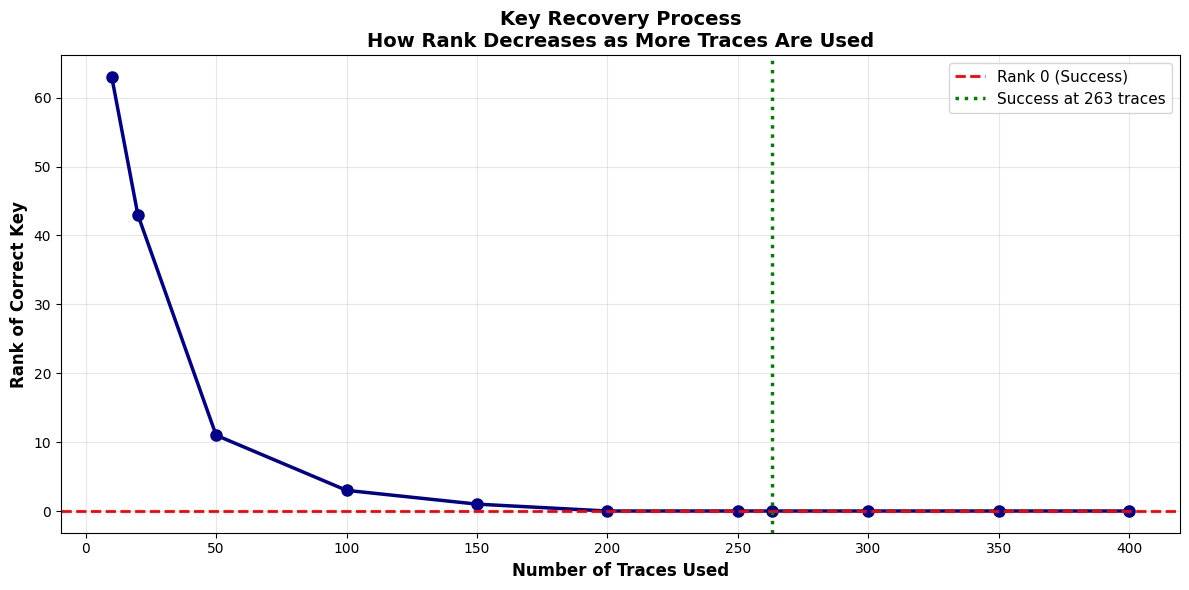


✓ Grafik kaydedildi: /content/drive/MyDrive/ASCAD_Results_Desync50/key_recovery_process.png


In [ ]:
# ATTACK SÜRECİNİ GÖRSELLEŞTİR
byte_idx = 2
nb_traces = 400

assert 'real_key' in globals(), "real_key tanımlı değil"

correct_key_byte = int(real_key[byte_idx])
print(f"Attacking byte {byte_idx}, correct key byte = {hex(correct_key_byte)}")


print("\n" + "="*60)
print("ATTACK SÜRECİ - TRACE SAYISI VS. RANK")
print("="*60)

trace_counts = [10, 20, 50, 100, 150, 200, 250, 263, 300, 350, 400]
ranks_over_time = []

for n_traces in trace_counts:
    key_scores_temp = np.zeros(256)

    for trace_idx in range(min(n_traces, len(predictions))):
        plaintext_byte = plt_attack[trace_idx][2]

        for key_guess in range(256):
            sbox_output = AES_Sbox[plaintext_byte ^ key_guess]
            key_scores_temp[key_guess] += np.log(predictions[trace_idx][sbox_output] + 1e-40)

    sorted_keys_temp = np.argsort(key_scores_temp)[::-1]
    rank_temp = np.where(sorted_keys_temp == correct_key_byte)[0][0]
    ranks_over_time.append(rank_temp)

    print(f"Trace sayısı: {n_traces:3d} → Rank: {rank_temp:3d}")

plt.figure(figsize=(12, 6))
plt.plot(trace_counts, ranks_over_time, 'o-', linewidth=2.5, markersize=8, color='darkblue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Rank 0 (Success)')
plt.axvline(x=263, color='green', linestyle=':', linewidth=2.5, label='Success at 263 traces')

plt.xlabel('Number of Traces Used', fontsize=12, fontweight='bold')
plt.ylabel('Rank of Correct Key', fontsize=12, fontweight='bold')
plt.title('Key Recovery Process\nHow Rank Decreases as More Traces Are Used',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{work_dir}/key_recovery_process.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Grafik kaydedildi: {work_dir}/key_recovery_process.png")

In [ ]:


import os, h5py, numpy as np, time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, Callback

ATM_PATH = "/content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ATMega8515_raw_traces.h5"
OUT_DIR  = "/content/atmega_masked_byte15"
os.makedirs(OUT_DIR, exist_ok=True)

TARGET_BYTE      = 15
N_PROF           = 50000

NB_EPOCHS        = 50
BATCH_SIZE       = 256
MAX_LR           = 1e-2
NB_TRACES_ATTACK = 1000
NB_ATTACKS       = 50

USE_MASK               = True
MASK_XOR_AFTER_SBOX    = True  # masked label = SBOX(pt^k) ^ mask_byte  (en yaygın)
MASK_FIELD_CANDIDATES  = [
    "mask", "masks", "output_mask", "sbox_mask", "byte_mask",
    "m", "rand", "random_mask"
]

# Byte 15 için SNR penceresini buraya yaz:
WINDOWS = {
    15: (10000, 20000),  # TODO: (ws, we) doldur (ör: (61600, 62300) gibi)
}

# =========================
# AES SBOX
# =========================
SBOX = np.array([
  0x63,0x7c,0x77,0x7b,0xf2,0x6b,0x6f,0xc5,0x30,0x01,0x67,0x2b,0xfe,0xd7,0xab,0x76,
  0xca,0x82,0xc9,0x7d,0xfa,0x59,0x47,0xf0,0xad,0xd4,0xa2,0xaf,0x9c,0xa4,0x72,0xc0,
  0xb7,0xfd,0x93,0x26,0x36,0x3f,0xf7,0xcc,0x34,0xa5,0xe5,0xf1,0x71,0xd8,0x31,0x15,
  0x04,0xc7,0x23,0xc3,0x18,0x96,0x05,0x9a,0x07,0x12,0x80,0xe2,0xeb,0x27,0xb2,0x75,
  0x09,0x83,0x2c,0x1a,0x1b,0x6e,0x5a,0xa0,0x52,0x3b,0xd6,0xb3,0x29,0xe3,0x2f,0x84,
  0x53,0xd1,0x00,0xed,0x20,0xfc,0xb1,0x5b,0x6a,0xcb,0xbe,0x39,0x4a,0x4c,0x58,0xcf,
  0xd0,0xef,0xaa,0xfb,0x43,0x4d,0x33,0x85,0x45,0xf9,0x02,0x7f,0x50,0x3c,0x9f,0xa8,
  0x51,0xa3,0x40,0x8f,0x92,0x9d,0x38,0xf5,0xbc,0xb6,0xda,0x21,0x10,0xff,0xf3,0xd2,
  0xcd,0x0c,0x13,0xec,0x5f,0x97,0x44,0x17,0xc4,0xa7,0x7e,0x3d,0x64,0x5d,0x19,0x73,
  0x60,0x81,0x4f,0xdc,0x22,0x2a,0x90,0x88,0x46,0xee,0xb8,0x14,0xde,0x5e,0x0b,0xdb,
  0xe0,0x32,0x3a,0x0a,0x49,0x06,0x24,0x5c,0xc2,0xd3,0xac,0x62,0x91,0x95,0xe4,0x79,
  0xe7,0xc8,0x37,0x6d,0x8d,0xd5,0x4e,0xa9,0x6c,0x56,0xf4,0xea,0x65,0x7a,0xae,0x08,
  0xba,0x78,0x25,0x2e,0x1c,0xa6,0xb4,0xc6,0xe8,0xdd,0x74,0x1f,0x4b,0xbd,0x8b,0x8a,
  0x70,0x3e,0xb5,0x66,0x48,0x03,0xf6,0x0e,0x61,0x35,0x57,0xb9,0x86,0xc1,0x1d,0x9e,
  0xe1,0xf8,0x98,0x11,0x69,0xd9,0x8e,0x94,0x9b,0x1e,0x87,0xe9,0xce,0x55,0x28,0xdf,
  0x8c,0xa1,0x89,0x0d,0xbf,0xe6,0x42,0x68,0x41,0x99,0x2d,0x0f,0xb0,0x54,0xbb,0x16
], dtype=np.uint8)

# =========================
# OneCycle LR
# =========================
class OneCycleLR(Callback):
    def __init__(self, max_lr, end_percentage=0.2, scale_percentage=0.1):
        super().__init__()
        self.max_lr         = max_lr
        self.min_lr         = max_lr * scale_percentage
        self.final_lr       = max_lr * scale_percentage * 0.1
        self.end_percentage = end_percentage
        self.iteration      = 0
        self.total_iter     = None

    def on_train_begin(self, logs=None):
        self.total_iter = self.params["steps"] * self.params["epochs"]
        self.phase1_end = int(self.total_iter * (1 - self.end_percentage))

    def on_train_batch_begin(self, batch, logs=None):
        it = self.iteration
        p1 = self.phase1_end
        p2 = max(self.total_iter - p1, 1)

        if it <= p1 // 2:
            lr = self.min_lr + (self.max_lr - self.min_lr) * it / max(p1 // 2, 1)
        elif it <= p1:
            lr = self.max_lr - (self.max_lr - self.min_lr) * (it - p1 // 2) / max(p1 // 2, 1)
        else:
            lr = self.min_lr - (self.min_lr - self.final_lr) * (it - p1) / p2

        try:
            self.model.optimizer.learning_rate.assign(float(lr))
        except Exception:
            self.model.optimizer.learning_rate = float(lr)

        self.iteration += 1

# =========================
# Model
# =========================
def build_model(input_len, lr=MAX_LR):
    init = keras.initializers.HeUniform()
    inp  = keras.Input(shape=(input_len, 1))

    x = layers.Conv1D(32,  1,  padding="same", activation="selu", kernel_initializer=init)(inp)
    x = layers.AveragePooling1D(2, strides=2)(x)

    x = layers.Conv1D(64,  25, padding="same", activation="selu", kernel_initializer=init)(x)
    x = layers.AveragePooling1D(25, strides=25)(x)

    x = layers.Conv1D(128, 3,  padding="same", activation="selu", kernel_initializer=init)(x)
    x = layers.AveragePooling1D(4,  strides=4)(x)

    x   = layers.Flatten()(x)
    x   = layers.Dense(15, activation="selu", kernel_initializer=init)(x)
    x   = layers.Dense(15, activation="selu", kernel_initializer=init)(x)
    x   = layers.Dense(15, activation="selu", kernel_initializer=init)(x)
    out = layers.Dense(256, activation="softmax")(x)

    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# =========================
# Mask extraction
# =========================
def _standardize_mask_array(mask_raw, n_traces, n_bytes=16):
    mask_raw = np.asarray(mask_raw)

    # case: (N, 16)
    if mask_raw.ndim == 2 and mask_raw.shape[0] == n_traces and mask_raw.shape[1] == n_bytes:
        return mask_raw.astype(np.uint8)

    # case: (N,) scalar-per-trace => replicate to 16 bytes
    if mask_raw.ndim == 1 and mask_raw.shape[0] == n_traces:
        m = mask_raw.astype(np.uint8)[:, None]
        return np.repeat(m, n_bytes, axis=1)

    # fallback: try to build (N, 16) with python loop
    try:
        built = []
        for v in mask_raw:
            arr = np.asarray(v)
            if arr.shape == (n_bytes,):
                built.append(arr.astype(np.uint8))
            elif arr.ndim == 0:
                built.append(np.repeat(np.uint8(arr), n_bytes))
            else:
                raise ValueError
        built = np.stack(built, axis=0)
        if built.shape == (n_traces, n_bytes):
            return built.astype(np.uint8)
    except Exception:
        pass

    raise ValueError(f"Mask şekli anlaşılamadı. mask_raw.shape={mask_raw.shape}, dtype={mask_raw.dtype}")

def extract_masks_from_metadata(md):
    if not hasattr(md, "dtype") or md.dtype.names is None:
        raise ValueError("metadata structured array değil; maske alanı aranamadı.")

    for name in MASK_FIELD_CANDIDATES:
        if name in md.dtype.names:
            mask_raw = md[name]
            masks = _standardize_mask_array(mask_raw, n_traces=len(md), n_bytes=16)
            print(f"✓ Maske alanı bulundu: '{name}' -> masks.shape={masks.shape}")
            return masks

    raise KeyError(
        "Masked attack için metadata içinde maske alanı bulunamadı. "
        f"Mevcut alanlar: {list(md.dtype.names)} | Arananlar: {MASK_FIELD_CANDIDATES}"
    )

# =========================
# Labels + attack
# =========================
def compute_labels_masked(pt_bytes, key_bytes, mask_bytes, byte):
    sbox_out = SBOX[np.bitwise_xor(pt_bytes[:, byte], key_bytes[:, byte])]
    if USE_MASK and MASK_XOR_AFTER_SBOX:
        return np.bitwise_xor(sbox_out, mask_bytes[:, byte]).astype(np.int64)
    return sbox_out.astype(np.int64)

def perform_attacks(model, Xa, pt_a, key_a, masks_a, byte,
                    nb_traces=1000, nb_attacks=50, seed=42):
    true_k = int(key_a[0, byte])
    N      = Xa.shape[0]
    rng    = np.random.default_rng(seed)

    if nb_traces > N:
        nb_traces = N

    print(f"    Predictions ({N} trace)...", end=" ", flush=True)
    all_preds = model.predict(Xa, verbose=0, batch_size=256)
    print("✓")

    pt_col   = pt_a[:, byte].astype(np.int32)
    k_arr    = np.arange(256, dtype=np.int32)

    sbox_mat = SBOX[np.bitwise_xor(pt_col[:, None], k_arr)]
    if USE_MASK and MASK_XOR_AFTER_SBOX:
        mask_col = masks_a[:, byte].astype(np.int32)
        cls_all  = np.bitwise_xor(sbox_mat, mask_col[:, None]).astype(np.int32)
    else:
        cls_all = sbox_mat.astype(np.int32)

    n_arr    = np.arange(N)[:, None]
    logp_all = np.log(all_preds[n_arr, cls_all] + 1e-40)

    ranks = np.zeros((nb_attacks, nb_traces), dtype=np.float32)
    for a in range(nb_attacks):
        idx = rng.choice(N, size=nb_traces, replace=False)
        cumlog = np.cumsum(logp_all[idx], axis=0)
        for t in range(nb_traces):
            ranks[a, t] = int(np.where(np.argsort(-cumlog[t]) == true_k)[0][0])

    avg_rank   = ranks.mean(axis=0)
    final_rank = float(avg_rank[-1])
    ntge_idx   = np.where(avg_rank == 0)[0]
    ntge       = int(ntge_idx[0] + 1) if len(ntge_idx) > 0 else -1
    return final_rank, ntge, avg_rank

# =========================
# MAIN
# =========================
def main():
    print("=" * 70)
    print("ATMega8515 — Masked Byte 15 Key Recovery")
    print("=" * 70)

    ws, we = WINDOWS[TARGET_BYTE]
    if we <= ws:
        raise ValueError(f"WINDOWS[{TARGET_BYTE}] geçersiz: ({ws},{we}). Byte 15 SNR penceresini doldur.")

    win_len = we - ws
    print(f"\nBYTE {TARGET_BYTE} | pencere=[{ws},{we}] ({win_len} sample) | USE_MASK={USE_MASK}")

    print("\nMetadata yükleniyor...")
    with h5py.File(ATM_PATH, "r") as f:
        md = f["metadata"][:]

    pt_all  = md["plaintext"].astype(np.uint8)
    key_all = md["key"].astype(np.uint8)

    if USE_MASK:
        masks_all = extract_masks_from_metadata(md)
    else:
        masks_all = np.zeros_like(pt_all, dtype=np.uint8)

    print(f"✓ Toplam trace: {len(pt_all)}")
    print(f"✓ True key (0. trace): {[hex(int(k)) for k in key_all[0]]}")

    pt_p,  key_p,  masks_p  = pt_all[:N_PROF],  key_all[:N_PROF],  masks_all[:N_PROF]
    pt_a,  key_a,  masks_a  = pt_all[N_PROF:],  key_all[N_PROF:],  masks_all[N_PROF:]

    print("\nTrace'ler yükleniyor...", end=" ", flush=True)
    with h5py.File(ATM_PATH, "r") as f:
        Xp_raw = f["traces"][:N_PROF, ws:we].astype(np.float32)
        Xa_raw = f["traces"][N_PROF:,  ws:we].astype(np.float32)
    print(f"✓ Xp={Xp_raw.shape}, Xa={Xa_raw.shape}")

    # standardize (profiling stats)
    mu  = Xp_raw.mean(axis=0, keepdims=True)
    std = Xp_raw.std(axis=0,  keepdims=True) + 1e-9
    Xp  = ((Xp_raw - mu) / std)[..., np.newaxis]
    Xa  = ((Xa_raw - mu) / std)[..., np.newaxis]

    # labels
    Y = compute_labels_masked(pt_p, key_p, masks_p, TARGET_BYTE)

    # train/val split (sabit kesim)
    X_tr, Y_tr = Xp[:45000], Y[:45000]
    X_va, Y_va = Xp[45000:], Y[45000:]

    model     = build_model(input_len=win_len, lr=MAX_LR)
    save_path = os.path.join(OUT_DIR, f"masked_byte{TARGET_BYTE:02d}.keras")
    model.summary()

    clr   = OneCycleLR(max_lr=MAX_LR)
    ckpt  = ModelCheckpoint(save_path, monitor="val_loss", save_best_only=True, verbose=0)
    early = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10,
        restore_best_weights=True, verbose=1
    )

    t0 = time.time()
    history = model.fit(
        X_tr, Y_tr,
        validation_data=(X_va, Y_va),
        epochs=NB_EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
        callbacks=[clr, ckpt, early]
    )
    best_val = float(min(history.history["val_loss"]))
    print(f"  Eğitim: {time.time()-t0:.0f}s | best_val_loss={best_val:.4f}")

    final_rank, ntge, avg_rank = perform_attacks(
        model, Xa, pt_a, key_a, masks_a, TARGET_BYTE,
        nb_traces=NB_TRACES_ATTACK,
        nb_attacks=NB_ATTACKS,
        seed=42 + TARGET_BYTE
    )

    np.save(os.path.join(OUT_DIR, f"ge_masked_byte{TARGET_BYTE:02d}.npy"), avg_rank)

    true_k = int(key_a[0, TARGET_BYTE])
    found  = final_rank < 5
    status = "BULUNDU" if found else "BULUNAMADI"
    print(f"\n  {status}")
    print(f"  Byte {TARGET_BYTE}: 0x{true_k:02x} | rank={final_rank:.1f} | NTGE={ntge}")
    print(f"\nSonuçlar: {OUT_DIR}/")

if __name__ == "__main__":
    main()

ATMega8515 — Masked Byte 15 Key Recovery

BYTE 15 | pencere=[10000,20000] (10000 sample) | USE_MASK=True

Metadata yükleniyor...
✓ Maske alanı bulundu: 'masks' -> masks.shape=(60000, 16)
✓ Toplam trace: 60000
✓ True key (0. trace): ['0x4d', '0xfb', '0xe0', '0xf2', '0x72', '0x21', '0xfe', '0x10', '0xa7', '0x8d', '0x4a', '0xdc', '0x8e', '0x49', '0x4', '0x69']

Trace'ler yükleniyor... ✓ Xp=(50000, 10000), Xa=(10000, 10000)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10000, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 10000, 32)      │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 5000, 32)       │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 5000, 64)       │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_1             │ (None, 200, 64)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 200, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_2             │ (None, 50, 128)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │        96,015 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │         4,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176,623 (689.93 KB)

 Trainable params: 176,623 (689.93 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 90s 404ms/step - accuracy: 0.0034 - loss: 5.6341 - val_accuracy: 0.0092 - val_loss: 5.4355
Epoch 2/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 59s 338ms/step - accuracy: 0.0128 - loss: 5.0887 - val_accuracy: 0.0258 - val_loss: 4.4356
Epoch 3/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 60s 341ms/step - accuracy: 0.0371 - loss: 4.2943 - val_accuracy: 0.0520 - val_loss: 3.8918
Epoch 4/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 60s 343ms/step - accuracy: 0.0645 - loss: 3.8255 - val_accuracy: 0.0688 - val_loss: 3.6980
Epoch 5/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 60s 343ms/step - accuracy: 0.0699 - loss: 3.6441 - val_accuracy: 0.0744 - val_loss: 3.6239
Epoch 6/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 60s 341ms/step - accuracy: 0.0765 - loss: 3.5993 - val_accuracy: 0.0700 - val_loss: 3.7808
Epoch 7/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 60s 343ms/step - accuracy: 0.0787 - loss: 3.5629 - val_accuracy: 0.0720 - val_loss: 3.6959
Epoch 8/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 60s 342ms/step - accuracy: 0.0766 - loss: 3

Ayarlar: {'BYTE_IDX': 15, 'N_TRACES': 20000, 'SAMPLE_START': 28000, 'SAMPLE_END': 34000, 'SAMPLE_STRIDE': 1}
H5 traces shape: (60000, 100000)
H5 metadata len : 60000
Reading traces   : (20000, 6000)
Metadata fields: ['plaintext', 'ciphertext', 'key', 'masks']
Mask field: masks
masks shape: (20000, 16) uint8
Byte 15 mask (first 10): [55, 67, 224, 235, 139, 175, 88, 89, 73, 73]
Byte 15 HW(mask) (first 10): [5, 3, 3, 6, 4, 6, 3, 4, 3, 3]

Özet:
  |corr(trace, HW(mask))| peak: 0.6667652726173401 at global sample 30980
  SNR(HW(mask)) peak           : 0.8019455075263977 at global sample 30980
  Top mask-bit corr peaks (bit, |corr|, global_sample):
    (7, 0.4134153425693512, 30977)
    (0, 0.30500033497810364, 30977)
    (2, 0.2945147454738617, 30977)
    (4, 0.29002800583839417, 30977)
    (5, 0.2849368453025818, 30977)


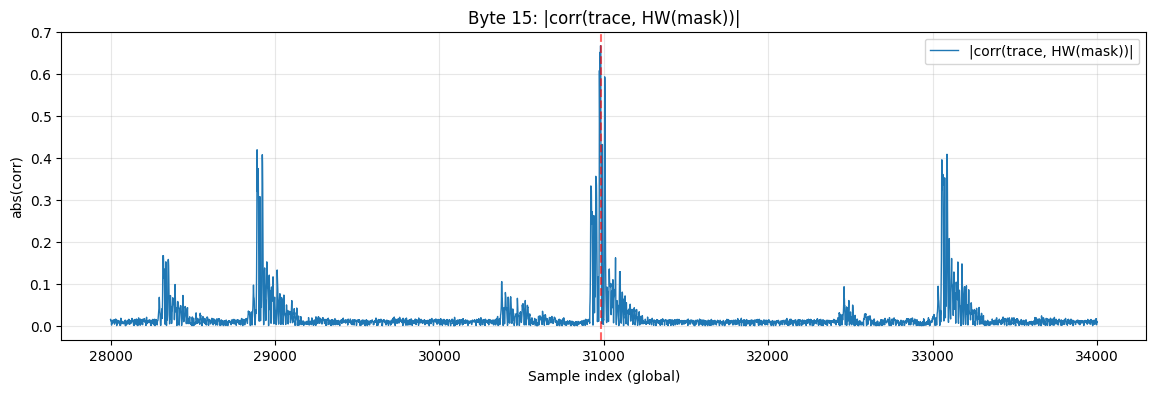

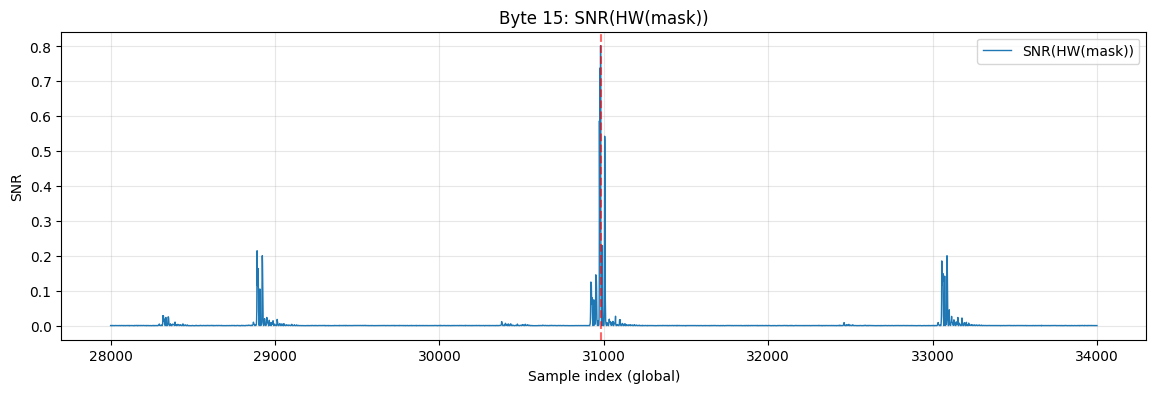

In [ ]:

# - Amaç: trace örnekleri ile mask'in (byte bazında) 1st-order sızıntısı var mı bakmak

# - Testler: corr(trace, HW(mask)), corr(trace, mask_bit), SNR(HW(mask))




import numpy as np

import h5py

import matplotlib.pyplot as plt




H5_PATH = "/content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ATMega8515_raw_traces.h5"




BYTE_IDX = 15  # 0..15

N_TRACES = 20000



# Çok uzun trace'lerde hız için örnek azalt:

SAMPLE_START = 28000

SAMPLE_END = 34000           # None => sonuna kadar

SAMPLE_STRIDE = 1           # 1 daha doğru ama yavaş; 5/10 genelde yeter



print('Ayarlar:', {'BYTE_IDX': BYTE_IDX, 'N_TRACES': N_TRACES, 'SAMPLE_START': SAMPLE_START, 'SAMPLE_END': SAMPLE_END, 'SAMPLE_STRIDE': SAMPLE_STRIDE})





# === YARDIMCILAR ===

HW = np.array([bin(i).count('1') for i in range(256)], dtype=np.uint8)



def _fields_of_struct_array(arr):

    return list(arr.dtype.names) if getattr(arr.dtype, 'names', None) is not None else []



def _standardize_masks(mask_arr, n_traces):

    m = np.asarray(mask_arr)



    # Bazı H5 structured alanları object gibi gelebilir

    if m.dtype == object:

        m = np.stack(m, axis=0)



    if m.shape[0] != n_traces:

        raise ValueError(f'mask first dim mismatch: got {m.shape[0]} expected {n_traces}')



    # (N,) ise tek-byte mask olabilir -> 16 byte'a kopyala

    if m.ndim == 1:

        m = np.tile(m[:, None], (1, 16))



    if m.ndim != 2 or m.shape[1] != 16:

        raise ValueError(f'unexpected mask shape (want N,16): {m.shape}')



    return m.astype(np.uint8, copy=False)



def find_mask_field(metadata):

    fields = _fields_of_struct_array(metadata)

    if not fields:

        raise ValueError('metadata structured değil (dtype.names yok).')



    candidates = [

        'masks', 'mask', 'mask_bytes', 'byte_mask', 'byte_masks',

        'output_mask', 'sbox_mask', 'sbox_masks', 'msk', 'msks'

    ]



    # 1) İsimden yakala

    for name in candidates:

        if name in fields:

            try:

                m = _standardize_masks(metadata[name], len(metadata))

                return name, m

            except Exception:

                pass



    # 2) Shape'ten yakala

    for name in fields:

        try:

            m = np.asarray(metadata[name])

            if m.ndim == 2 and m.shape[0] == len(metadata) and m.shape[1] == 16:

                m2 = _standardize_masks(m, len(metadata))

                return name, m2

        except Exception:

            continue



    raise ValueError(f'Mask alanı bulunamadı. Fields: {fields}')



def corr_per_sample(X, y):

    # Pearson corr for each column

    X = np.asarray(X, dtype=np.float32)

    y = np.asarray(y, dtype=np.float32)

    y = y - y.mean()

    y_var = (y * y).mean()

    if y_var < 1e-12:

        return np.zeros(X.shape[1], dtype=np.float32)



    Xc = X - X.mean(axis=0, keepdims=True)

    cov = (Xc * y[:, None]).mean(axis=0)

    x_var = (Xc * Xc).mean(axis=0)

    denom = np.sqrt(x_var * y_var) + 1e-12

    return (cov / denom).astype(np.float32)



def snr_hw(X, hw_labels):

    # SNR = Var(E[X|c]) / E[Var(X|c)]  for c in 0..8

    X = np.asarray(X, dtype=np.float32)

    hw_labels = np.asarray(hw_labels)

    N, T = X.shape



    mu = X.mean(axis=0)

    var_between = np.zeros(T, dtype=np.float64)

    var_within = np.zeros(T, dtype=np.float64)



    for c in range(9):

        idx = (hw_labels == c)

        n = int(idx.sum())

        if n < 2:

            continue

        Xc = X[idx]

        muc = Xc.mean(axis=0)

        varc = Xc.var(axis=0)

        pc = n / N

        var_between += pc * (muc - mu) ** 2

        var_within += pc * varc



    return (var_between / (var_within + 1e-12)).astype(np.float32)


with h5py.File(H5_PATH, 'r') as f:

    traces_ds = f['traces']

    md_ds = f['metadata']



    total_traces = traces_ds.shape[0]

    total_samples = traces_ds.shape[1]



    n = min(int(N_TRACES), int(total_traces))

    s0 = int(SAMPLE_START)

    s1 = int(total_samples) if SAMPLE_END is None else int(SAMPLE_END)

    stride = int(SAMPLE_STRIDE)



    print('H5 traces shape:', traces_ds.shape)

    print('H5 metadata len :', md_ds.shape[0])

    print('Reading traces   :', (n, (s1 - s0 + stride - 1) // stride))



    traces = traces_ds[:n, s0:s1:stride].astype(np.float32)

    metadata = md_ds[:n]



fields = _fields_of_struct_array(metadata)

print('Metadata fields:', fields)





# === MASK ÇIKAR ===

mask_field, masks = find_mask_field(metadata)

mask_b = masks[:, int(BYTE_IDX)]



mask_hw_labels = HW[mask_b]

mask_bits = ((mask_b[:, None] >> np.arange(8)) & 1).astype(np.uint8)



print('Mask field:', mask_field)

print('masks shape:', masks.shape, masks.dtype)

print(f'Byte {BYTE_IDX} mask (first 10):', mask_b[:10].tolist())

print(f'Byte {BYTE_IDX} HW(mask) (first 10):', mask_hw_labels[:10].tolist())





# === KORELASYON + SNR ===

corr_hw_vals = corr_per_sample(traces, mask_hw_labels)

peak_corr_i = int(np.argmax(np.abs(corr_hw_vals)))



bit_peaks = []

for b in range(8):

    c = corr_per_sample(traces, mask_bits[:, b])

    pi = int(np.argmax(np.abs(c)))

    bit_peaks.append((b, float(np.abs(c[pi])), pi))

bit_peaks.sort(key=lambda x: x[1], reverse=True)



snr_vals = snr_hw(traces, mask_hw_labels)

peak_snr_i = int(np.argmax(snr_vals))



x_axis = np.arange(traces.shape[1]) * stride + s0

print('\nÖzet:')

print('  |corr(trace, HW(mask))| peak:', float(np.abs(corr_hw_vals[peak_corr_i])), 'at global sample', int(x_axis[peak_corr_i]))

print('  SNR(HW(mask)) peak           :', float(snr_vals[peak_snr_i]), 'at global sample', int(x_axis[peak_snr_i]))

print('  Top mask-bit corr peaks (bit, |corr|, global_sample):')

for (b, v, pi) in bit_peaks[:5]:

    print('   ', (b, v, int(x_axis[pi])))





# === PLOT ===

plt.figure(figsize=(14, 4))

plt.plot(x_axis, np.abs(corr_hw_vals), linewidth=1, label='|corr(trace, HW(mask))|')

plt.axvline(int(x_axis[peak_corr_i]), color='r', linestyle='--', alpha=0.6)

plt.title(f'Byte {BYTE_IDX}: |corr(trace, HW(mask))|')

plt.xlabel('Sample index (global)')

plt.ylabel('abs(corr)')

plt.grid(True, alpha=0.3)

plt.legend()

plt.show()



plt.figure(figsize=(14, 4))

plt.plot(x_axis, snr_vals, linewidth=1, label='SNR(HW(mask))')

plt.axvline(int(x_axis[peak_snr_i]), color='r', linestyle='--', alpha=0.6)

plt.title(f'Byte {BYTE_IDX}: SNR(HW(mask))')

plt.xlabel('Sample index (global)')

plt.ylabel('SNR')

plt.grid(True, alpha=0.3)

plt.legend()

plt.show()

TF: 2.19.0
traces shape: (60000, 100000)
metadata fields: ['plaintext', 'ciphertext', 'key', 'masks']
Window1 (masked-value): (18472, 19172) len 700
Window2 (mask-share)  : (30630, 31330) len 700
n_prof: 50000 n_att: 10000
X_prof_raw: (50000, 1400) X_att_raw: (10000, 1400)
Y_prof unique: 256 real key byte: 0x69
CNN input: (50000, 1400, 1) input_len: 1400


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1400, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 1400, 16)       │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1400, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_3             │ (None, 700, 16)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 700, 32)        │         5,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 700, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_4             │ (None, 350, 32)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 350, 64)        │        22,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 350, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_5             │ (None, 175, 64)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 11200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 200)            │     2,240,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        51,456 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,360,752 (9.01 MB)

 Trainable params: 2,360,528 (9.00 MB)

 Non-trainable params: 224 (896.00 B)

Epoch 1/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.0042 - loss: 6.5937
Epoch 1: val_accuracy improved from -inf to 0.00420, saving model to /content/out_unmasked_byte15/model_unmasked_byte15.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - accuracy: 0.0042 - loss: 6.5902 - val_accuracy: 0.0042 - val_loss: 5.6670
Epoch 2/50
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.0060 - loss: 5.6106
Epoch 2: val_accuracy did not improve from 0.00420
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.0060 - loss: 5.6105 - val_accuracy: 0.0026 - val_loss: 5.6698
Epoch 3/50
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.0096 - loss: 5.5403
Epoch 3: val_accuracy did not improve from 0.00420
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.0096 - loss: 5.5401 - val_accuracy: 0.0032 - val_loss: 5.7012
Epoch 4/50
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.0196 - loss: 5.4310
Epoch 4: val_accuracy did not improve from 0.00420
176/176 ━━━━━━━━

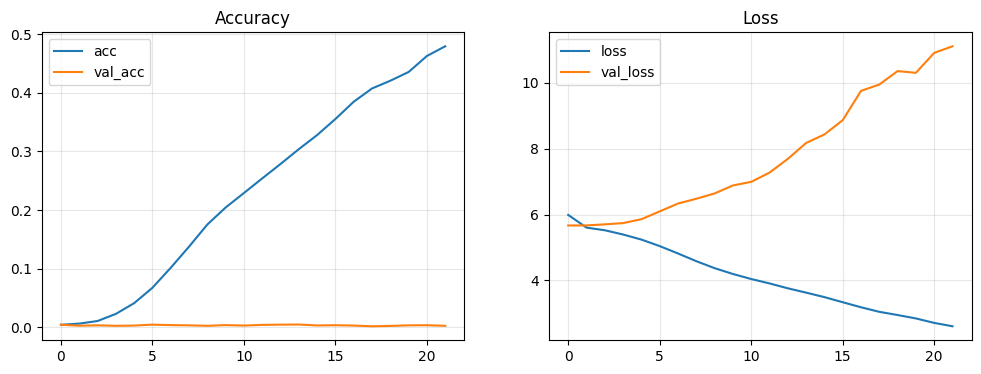


=== SONUÇ (MASK BİLMEDEN) ===
True key byte[15] : 0x69
Best key guess    : 0x54
Final rank        : 193
NTGE (GE_mean==0) : None


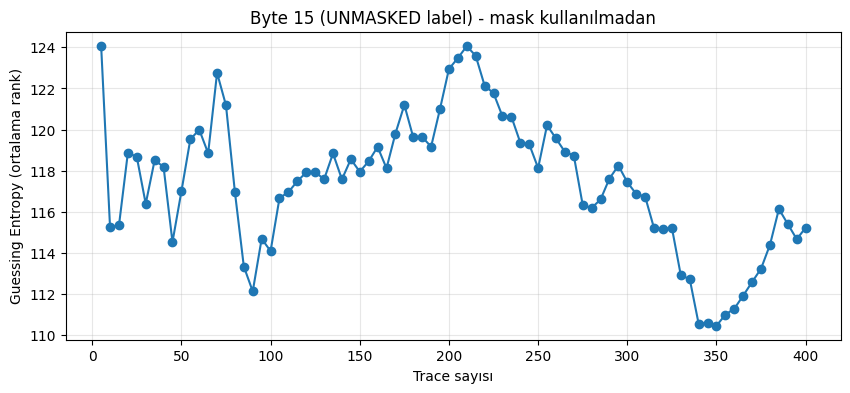

Saved: /content/out_unmasked_byte15


In [ ]:
# Colab: Byte 15 key recovery (MASK BİLMEDEN) - DÜZELTİLMİŞ TAM KOD
# - masks metadata'sı HİÇ kullanılmaz
# - profiling label: UNMASKED  y = SBOX(pt ^ key)
# - input: iki pencere concat (masked-value bölgesi + mask-share leakage bölgesi)
# - attack: GE/NTGE + final rank (take_along_axis ile düzgün indexing)

import os
import numpy as np
import h5py
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, AveragePooling1D, BatchNormalization, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

print("TF:", tf.__version__)



# =====================
# AYARLAR
# =====================
H5_PATH = "/content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ATMega8515_raw_traces.h5"

TARGET_BYTE = 15

# Senin bulduğun peak'ler:
PEAK_MASKED_VALUE = 18822   # masked-value leakage bölgesi (senin masked SNR tepe)
PEAK_MASK_SHARE   = 30980   # mask share leakage bölgesi (corr/SNR(HW(mask)) tepe)

WIN_LEN = 700
HALF = WIN_LEN // 2

N_PROF = 50000            # profiling traces
N_ATTACK_USE = 10000      # attack tarafında kullanacağımız trace sayısı (hız için)

EPOCHS = 50
BATCH = 256
LR = 1e-3

NB_TRACES_ATTACK = 400
NB_ATTACKS = 100
TRACE_STEP = 5            # GE'yi her kaç trace'te bir ölçelim

OUT_DIR = "/content/out_unmasked_byte15"
os.makedirs(OUT_DIR, exist_ok=True)

# Reproducibility
np.random.seed(123)
tf.random.set_seed(123)

# =====================
# AES S-Box
# =====================
AES_Sbox = np.array([
    0x63,0x7c,0x77,0x7b,0xf2,0x6b,0x6f,0xc5,0x30,0x01,0x67,0x2b,0xfe,0xd7,0xab,0x76,
    0xca,0x82,0xc9,0x7d,0xfa,0x59,0x47,0xf0,0xad,0xd4,0xa2,0xaf,0x9c,0xa4,0x72,0xc0,
    0xb7,0xfd,0x93,0x26,0x36,0x3f,0xf7,0xcc,0x34,0xa5,0xe5,0xf1,0x71,0xd8,0x31,0x15,
    0x04,0xc7,0x23,0xc3,0x18,0x96,0x05,0x9a,0x07,0x12,0x80,0xe2,0xeb,0x27,0xb2,0x75,
    0x09,0x83,0x2c,0x1a,0x1b,0x6e,0x5a,0xa0,0x52,0x3b,0xd6,0xb3,0x29,0xe3,0x2f,0x84,
    0x53,0xd1,0x00,0xed,0x20,0xfc,0xb1,0x5b,0x6a,0xcb,0xbe,0x39,0x4a,0x4c,0x58,0xcf,
    0xd0,0xef,0xaa,0xfb,0x43,0x4d,0x33,0x85,0x45,0xf9,0x02,0x7f,0x50,0x3c,0x9f,0xa8,
    0x51,0xa3,0x40,0x8f,0x92,0x9d,0x38,0xf5,0xbc,0xb6,0xda,0x21,0x10,0xff,0xf3,0xd2,
    0xcd,0x0c,0x13,0xec,0x5f,0x97,0x44,0x17,0xc4,0xa7,0x7e,0x3d,0x64,0x5d,0x19,0x73,
    0x60,0x81,0x4f,0xdc,0x22,0x2a,0x90,0x88,0x46,0xee,0xb8,0x14,0xde,0x5e,0x0b,0xdb,
    0xe0,0x32,0x3a,0x0a,0x49,0x06,0x24,0x5c,0xc2,0xd3,0xac,0x62,0x91,0x95,0xe4,0x79,
    0xe7,0xc8,0x37,0x6d,0x8d,0xd5,0x4e,0xa9,0x6c,0x56,0xf4,0xea,0x65,0x7a,0xae,0x08,
    0xba,0x78,0x25,0x2e,0x1c,0xa6,0xb4,0xc6,0xe8,0xdd,0x74,0x1f,0x4b,0xbd,0x8b,0x8a,
    0x70,0x3e,0xb5,0x66,0x48,0x03,0xf6,0x0e,0x61,0x35,0x57,0xb9,0x86,0xc1,0x1d,0x9e,
    0xe1,0xf8,0x98,0x11,0x69,0xd9,0x8e,0x94,0x9b,0x1e,0x87,0xe9,0xce,0x55,0x28,0xdf,
    0x8c,0xa1,0x89,0x0d,0xbf,0xe6,0x42,0x68,0x41,0x99,0x2d,0x0f,0xb0,0x54,0xbb,0x16
], dtype=np.uint8)

def window_indices(peak, half, n_samples):
    ws = max(0, int(peak - half))
    we = min(n_samples, int(peak + half))
    if we - ws < 2 * half:
        ws = max(0, we - 2 * half)
        we = min(n_samples, ws + 2 * half)
    return ws, we

def build_cnn(input_len, lr=1e-3, classes=256):
    inp = Input(shape=(input_len, 1))
    x = Conv1D(16, 11, activation="selu", padding="same", kernel_initializer="he_uniform")(inp)
    x = BatchNormalization()(x)
    x = AveragePooling1D(2)(x)

    x = Conv1D(32, 11, activation="selu", padding="same", kernel_initializer="he_uniform")(x)
    x = BatchNormalization()(x)
    x = AveragePooling1D(2)(x)

    x = Conv1D(64, 11, activation="selu", padding="same", kernel_initializer="he_uniform")(x)
    x = BatchNormalization()(x)
    x = AveragePooling1D(2)(x)

    x = Flatten()(x)
    x = Dense(200, activation="selu", kernel_initializer="he_uniform")(x)
    x = Dense(200, activation="selu", kernel_initializer="he_uniform")(x)
    out = Dense(classes, activation="softmax")(x)

    m = Model(inp, out)
    m.compile(optimizer=Adam(learning_rate=lr),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
    return m

def rank_of_key(scores, true_k):
    order = np.argsort(scores)[::-1]
    return int(np.where(order == true_k)[0][0])

# =====================
# H5: SADECE gerekli pencereleri oku (RAM dostu)
# =====================
with h5py.File(H5_PATH, "r") as f:
    traces_ds = f["traces"]
    md_ds = f["metadata"]
    total_traces, total_samples = traces_ds.shape

    n_prof = min(int(N_PROF), int(total_traces))
    n_att  = min(int(N_ATTACK_USE), int(total_traces) - n_prof)

    ws1, we1 = window_indices(PEAK_MASKED_VALUE, HALF, total_samples)
    ws2, we2 = window_indices(PEAK_MASK_SHARE,   HALF, total_samples)

    print("traces shape:", traces_ds.shape)
    print("metadata fields:", list(md_ds.dtype.names))
    print("Window1 (masked-value):", (ws1, we1), "len", we1-ws1)
    print("Window2 (mask-share)  :", (ws2, we2), "len", we2-ws2)
    print("n_prof:", n_prof, "n_att:", n_att)

    # Profiling windows
    w1_prof = traces_ds[:n_prof, ws1:we1].astype(np.float32)
    w2_prof = traces_ds[:n_prof, ws2:we2].astype(np.float32)
    X_prof_raw = np.concatenate([w1_prof, w2_prof], axis=1)  # (n_prof, 1400)

    md_prof = md_ds[:n_prof]
    pt_prof = md_prof["plaintext"].astype(np.uint8)
    key_prof = md_prof["key"].astype(np.uint8)

    # UNMASKED label: y = SBOX(pt ^ key)
    Y_prof = AES_Sbox[pt_prof[:, TARGET_BYTE] ^ key_prof[:, TARGET_BYTE]].astype(np.uint8)

    real_key = int(key_prof[0, TARGET_BYTE])
    # (Eval için) key sabit mi kontrol (çok maliyetli değil)
    if not np.all(key_prof[:, TARGET_BYTE] == real_key):
        print("UYARI: Profiling key byte sabit değil gibi görünüyor!")

    # Attack windows
    w1_att = traces_ds[n_prof:n_prof+n_att, ws1:we1].astype(np.float32)
    w2_att = traces_ds[n_prof:n_prof+n_att, ws2:we2].astype(np.float32)
    X_att_raw = np.concatenate([w1_att, w2_att], axis=1)      # (n_att, 1400)

    md_att = md_ds[n_prof:n_prof+n_att]
    pt_att = md_att["plaintext"].astype(np.uint8)

print("X_prof_raw:", X_prof_raw.shape, "X_att_raw:", X_att_raw.shape)
print("Y_prof unique:", len(np.unique(Y_prof)), "real key byte:", hex(real_key))

# =====================
# Normalize (profiling mean/std) + CNN shape
# =====================
mu = X_prof_raw.mean(axis=0, keepdims=True)
sigma = X_prof_raw.std(axis=0, keepdims=True) + 1e-8

X_prof = ((X_prof_raw - mu) / sigma).astype(np.float32)[..., None]
X_att  = ((X_att_raw  - mu) / sigma).astype(np.float32)[..., None]

input_len = X_prof.shape[1]
print("CNN input:", X_prof.shape, "input_len:", input_len)

# =====================
# Train
# =====================
model = build_cnn(input_len=input_len, lr=LR, classes=256)
model.summary()

ckpt_path = os.path.join(OUT_DIR, "model_unmasked_byte15.keras")
callbacks = [
    ModelCheckpoint(ckpt_path, monitor="val_accuracy", mode="max", save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_accuracy", mode="max", patience=8, restore_best_weights=True, verbose=1),
]

# 45k / 5k split (profiling 50k varsayımıyla)
split = min(45000, X_prof.shape[0] - 1)
X_tr, Y_tr = X_prof[:split], Y_prof[:split]
X_va, Y_va = X_prof[split:], Y_prof[split:]

hist = model.fit(
    X_tr, Y_tr,
    validation_data=(X_va, Y_va),
    epochs=EPOCHS,
    batch_size=BATCH,
    verbose=1,
    callbacks=callbacks,
)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(hist.history["accuracy"], label="acc")
plt.plot(hist.history["val_accuracy"], label="val_acc")
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(hist.history["loss"], label="loss")
plt.plot(hist.history["val_loss"], label="val_loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("Loss")
plt.show()

# =====================
# Attack (mask YOK) - DÜZELTİLMİŞ gather
# =====================
pred = model.predict(X_att, batch_size=512, verbose=0)
log_pred = np.log(pred + 1e-36).astype(np.float32)  # (n_att, 256)

pt_b = pt_att[:, TARGET_BYTE].astype(np.uint8)
keys = np.arange(256, dtype=np.uint8)

# expected class table: (n_att, 256)
expected_all = AES_Sbox[pt_b[:, None] ^ keys[None, :]].astype(np.int64)

# gathered[i, k] = log_pred[i, expected_all[i,k]]
gathered = np.take_along_axis(log_pred, expected_all, axis=1).astype(np.float32)  # (n_att, 256)

rng = np.random.default_rng(123)

counts = np.arange(TRACE_STEP, NB_TRACES_ATTACK + 1, TRACE_STEP, dtype=np.int32)
ge_sum = np.zeros_like(counts, dtype=np.float64)

for a in range(NB_ATTACKS):
    idxs = rng.choice(len(X_att), size=NB_TRACES_ATTACK, replace=False)
    ll = gathered[idxs]                 # (NB_TRACES_ATTACK, 256)
    cs = np.cumsum(ll, axis=0)          # (t, 256)

    ranks = []
    for t in counts:
        ranks.append(rank_of_key(cs[t-1], real_key))
    ge_sum += np.array(ranks, dtype=np.float64)

ge_mean = ge_sum / NB_ATTACKS

ntge = None
for t, g in zip(counts, ge_mean):
    if g == 0:
        ntge = int(t)
        break

# Final rank (deterministic): first NB_TRACES_ATTACK traces (0..)
scores0 = gathered[:NB_TRACES_ATTACK].sum(axis=0).astype(np.float64)
best_k = int(np.argmax(scores0))
final_rank = rank_of_key(scores0, real_key)

print("\n=== SONUÇ (MASK BİLMEDEN) ===")
print("True key byte[15] :", hex(real_key))
print("Best key guess    :", hex(best_k))
print("Final rank        :", final_rank)
print("NTGE (GE_mean==0) :", ntge)

plt.figure(figsize=(10,4))
plt.plot(counts, ge_mean, marker="o")
plt.grid(True, alpha=0.3)
plt.xlabel("Trace sayısı")
plt.ylabel("Guessing Entropy (ortalama rank)")
plt.title("Byte 15 (UNMASKED label) - mask kullanılmadan")
plt.show()

np.save(os.path.join(OUT_DIR, "ge_counts.npy"), counts)
np.save(os.path.join(OUT_DIR, "ge_mean.npy"), ge_mean)
print("Saved:", OUT_DIR)

In [ ]:
# Colab: Byte 15 key recovery (MASK BİLMEDEN) - shuffle split + fixed gather
import os
import numpy as np
import h5py
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, AveragePooling1D, BatchNormalization, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

print("TF:", tf.__version__)
np.random.seed(123)
tf.random.set_seed(123)

H5_PATH = "/content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ATMega8515_raw_traces.h5"
TARGET_BYTE = 15

PEAK_MASKED_VALUE = 18822
PEAK_MASK_SHARE   = 30980

WIN_LEN = 700
HALF = WIN_LEN // 2

N_PROF = 50000
N_ATTACK_USE = 10000

EPOCHS = 50
BATCH = 256
LR = 1e-3

NB_TRACES_ATTACK = 400
NB_ATTACKS = 100
TRACE_STEP = 5

OUT_DIR = "/content/out_unmasked_byte15"
os.makedirs(OUT_DIR, exist_ok=True)

AES_Sbox = np.array([
    0x63,0x7c,0x77,0x7b,0xf2,0x6b,0x6f,0xc5,0x30,0x01,0x67,0x2b,0xfe,0xd7,0xab,0x76,
    0xca,0x82,0xc9,0x7d,0xfa,0x59,0x47,0xf0,0xad,0xd4,0xa2,0xaf,0x9c,0xa4,0x72,0xc0,
    0xb7,0xfd,0x93,0x26,0x36,0x3f,0xf7,0xcc,0x34,0xa5,0xe5,0xf1,0x71,0xd8,0x31,0x15,
    0x04,0xc7,0x23,0xc3,0x18,0x96,0x05,0x9a,0x07,0x12,0x80,0xe2,0xeb,0x27,0xb2,0x75,
    0x09,0x83,0x2c,0x1a,0x1b,0x6e,0x5a,0xa0,0x52,0x3b,0xd6,0xb3,0x29,0xe3,0x2f,0x84,
    0x53,0xd1,0x00,0xed,0x20,0xfc,0xb1,0x5b,0x6a,0xcb,0xbe,0x39,0x4a,0x4c,0x58,0xcf,
    0xd0,0xef,0xaa,0xfb,0x43,0x4d,0x33,0x85,0x45,0xf9,0x02,0x7f,0x50,0x3c,0x9f,0xa8,
    0x51,0xa3,0x40,0x8f,0x92,0x9d,0x38,0xf5,0xbc,0xb6,0xda,0x21,0x10,0xff,0xf3,0xd2,
    0xcd,0x0c,0x13,0xec,0x5f,0x97,0x44,0x17,0xc4,0xa7,0x7e,0x3d,0x64,0x5d,0x19,0x73,
    0x60,0x81,0x4f,0xdc,0x22,0x2a,0x90,0x88,0x46,0xee,0xb8,0x14,0xde,0x5e,0x0b,0xdb,
    0xe0,0x32,0x3a,0x0a,0x49,0x06,0x24,0x5c,0xc2,0xd3,0xac,0x62,0x91,0x95,0xe4,0x79,
    0xe7,0xc8,0x37,0x6d,0x8d,0xd5,0x4e,0xa9,0x6c,0x56,0xf4,0xea,0x65,0x7a,0xae,0x08,
    0xba,0x78,0x25,0x2e,0x1c,0xa6,0xb4,0xc6,0xe8,0xdd,0x74,0x1f,0x4b,0xbd,0x8b,0x8a,
    0x70,0x3e,0xb5,0x66,0x48,0x03,0xf6,0x0e,0x61,0x35,0x57,0xb9,0x86,0xc1,0x1d,0x9e,
    0xe1,0xf8,0x98,0x11,0x69,0xd9,0x8e,0x94,0x9b,0x1e,0x87,0xe9,0xce,0x55,0x28,0xdf,
    0x8c,0xa1,0x89,0x0d,0xbf,0xe6,0x42,0x68,0x41,0x99,0x2d,0x0f,0xb0,0x54,0xbb,0x16
], dtype=np.uint8)

def window_indices(peak, half, n_samples):
    ws = max(0, int(peak - half))
    we = min(n_samples, int(peak + half))
    if we - ws < 2 * half:
        ws = max(0, we - 2 * half)
        we = min(n_samples, ws + 2 * half)
    return ws, we

def build_cnn(input_len, lr=1e-3, classes=256):
    inp = Input(shape=(input_len, 1))
    x = Conv1D(16, 11, activation="selu", padding="same", kernel_initializer="he_uniform")(inp)
    x = BatchNormalization()(x); x = AveragePooling1D(2)(x)
    x = Conv1D(32, 11, activation="selu", padding="same", kernel_initializer="he_uniform")(x)
    x = BatchNormalization()(x); x = AveragePooling1D(2)(x)
    x = Conv1D(64, 11, activation="selu", padding="same", kernel_initializer="he_uniform")(x)
    x = BatchNormalization()(x); x = AveragePooling1D(2)(x)
    x = Flatten()(x)
    x = Dense(200, activation="selu", kernel_initializer="he_uniform")(x)
    x = Dense(200, activation="selu", kernel_initializer="he_uniform")(x)
    out = Dense(classes, activation="softmax")(x)
    m = Model(inp, out)
    m.compile(optimizer=Adam(learning_rate=lr), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

def rank_of_key(scores, true_k):
    order = np.argsort(scores)[::-1]
    return int(np.where(order == true_k)[0][0])

with h5py.File(H5_PATH, "r") as f:
    traces_ds = f["traces"]
    md_ds = f["metadata"]
    total_traces, total_samples = traces_ds.shape

    n_prof = min(N_PROF, total_traces)
    n_att  = min(N_ATTACK_USE, total_traces - n_prof)

    ws1, we1 = window_indices(PEAK_MASKED_VALUE, HALF, total_samples)
    ws2, we2 = window_indices(PEAK_MASK_SHARE,   HALF, total_samples)
    print("Window1:", (ws1, we1), "Window2:", (ws2, we2))

    w1_prof = traces_ds[:n_prof, ws1:we1].astype(np.float32)
    w2_prof = traces_ds[:n_prof, ws2:we2].astype(np.float32)
    X_prof_raw = np.concatenate([w1_prof, w2_prof], axis=1)

    md_prof = md_ds[:n_prof]
    pt_prof = md_prof["plaintext"].astype(np.uint8)
    key_prof = md_prof["key"].astype(np.uint8)

    Y_prof = AES_Sbox[pt_prof[:, TARGET_BYTE] ^ key_prof[:, TARGET_BYTE]].astype(np.uint8)
    real_key = int(key_prof[0, TARGET_BYTE])
    print("Real key byte[15]:", hex(real_key))

    w1_att = traces_ds[n_prof:n_prof+n_att, ws1:we1].astype(np.float32)
    w2_att = traces_ds[n_prof:n_prof+n_att, ws2:we2].astype(np.float32)
    X_att_raw = np.concatenate([w1_att, w2_att], axis=1)

    md_att = md_ds[n_prof:n_prof+n_att]
    pt_att = md_att["plaintext"].astype(np.uint8)

# normalize
mu = X_prof_raw.mean(axis=0, keepdims=True)
sigma = X_prof_raw.std(axis=0, keepdims=True) + 1e-8
X_prof = ((X_prof_raw - mu) / sigma).astype(np.float32)
X_att  = ((X_att_raw  - mu) / sigma).astype(np.float32)

# RANDOM split (kritik fix)
idx = np.arange(X_prof.shape[0])
idx_tr, idx_va = train_test_split(idx, test_size=0.1, random_state=123, shuffle=True)

X_tr = X_prof[idx_tr][..., None]
Y_tr = Y_prof[idx_tr]
X_va = X_prof[idx_va][..., None]
Y_va = Y_prof[idx_va]

X_att = X_att[..., None]
print("Train/Val:", X_tr.shape, X_va.shape, "Attack:", X_att.shape)

model = build_cnn(input_len=X_tr.shape[1], lr=LR, classes=256)
ckpt_path = os.path.join(OUT_DIR, "model_unmasked_byte15.keras")
callbacks = [
    ModelCheckpoint(ckpt_path, monitor="val_accuracy", mode="max", save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_accuracy", mode="max", patience=8, restore_best_weights=True, verbose=1),
]
hist = model.fit(X_tr, Y_tr, validation_data=(X_va, Y_va), epochs=EPOCHS, batch_size=BATCH, verbose=1, callbacks=callbacks)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.plot(hist.history["accuracy"]); plt.plot(hist.history["val_accuracy"]); plt.grid(True, alpha=0.3); plt.title("acc")
plt.subplot(1,2,2); plt.plot(hist.history["loss"]); plt.plot(hist.history["val_loss"]); plt.grid(True, alpha=0.3); plt.title("loss")
plt.show()



TF: 2.19.0
Window1: (18472, 19172) Window2: (30630, 31330)


In [ ]:
# attack
pred = model.predict(X_att, batch_size=512, verbose=0)
log_pred = np.log(pred + 1e-36).astype(np.float32)

pt_b = pt_att[:, TARGET_BYTE].astype(np.uint8)
keys = np.arange(256, dtype=np.uint8)
expected_all = AES_Sbox[pt_b[:, None] ^ keys[None, :]].astype(np.int64)

gathered = np.take_along_axis(log_pred, expected_all, axis=1).astype(np.float32)

rng = np.random.default_rng(123)
counts = np.arange(TRACE_STEP, NB_TRACES_ATTACK + 1, TRACE_STEP, dtype=np.int32)
ge_sum = np.zeros_like(counts, dtype=np.float64)

for a in range(NB_ATTACKS):
    idxs = rng.choice(gathered.shape[0], size=NB_TRACES_ATTACK, replace=False)
    cs = np.cumsum(gathered[idxs], axis=0)
    ranks = [rank_of_key(cs[t-1], real_key) for t in counts]
    ge_sum += np.array(ranks, dtype=np.float64)

ge_mean = ge_sum / NB_ATTACKS
ntge = next((int(t) for t, g in zip(counts, ge_mean) if g == 0), None)

In [ ]:


scores0 = gathered[:NB_TRACES_ATTACK].sum(axis=0).astype(np.float64)
best_k = int(np.argmax(scores0))
final_rank = rank_of_key(scores0, real_key)

print("\n=== SONUÇ (MASK BİLMEDEN) ===")
print("True key byte[15] :", hex(real_key))
print("Best key guess    :", hex(best_k))
print("Final rank        :", final_rank)
print("NTGE              :", ntge)

plt.figure(figsize=(10,4))
plt.plot(counts, ge_mean, marker="o")
plt.grid(True, alpha=0.3)
plt.xlabel("Trace sayısı")
plt.ylabel("Guessing Entropy (ortalama rank)")
plt.title("Byte 15 (UNMASKED label) - mask kullanılmadan")
plt.show()

Profiling label için kullanılan gerçek key byte: 0x69
Processed 2000/50000 traces...
Processed 12000/50000 traces...
Processed 22000/50000 traces...
Processed 32000/50000 traces...
Processed 42000/50000 traces...

=== UNMASKED-LABEL SNR SONUÇ ===
Peak SNR: 0.0008865302079357207 at global sample: 1620
HW class counts: {0: 209, 1: 1521, 2: 5435, 3: 11093, 4: 13570, 5: 10980, 6: 5388, 7: 1601, 8: 203}

Top peaks (SNR, global_sample):
  0.0008865302079357207 1620
  0.0007459877524524927 46464
  0.0006912220269441605 31892
  0.000689757289364934 17052
  0.0006358827231451869 45412
  0.000616932287812233 29846
  0.0006113942945376039 8540
  0.0005932747735641897 12732
  0.0005889530293643475 77306
  0.0005589601350948215 7268


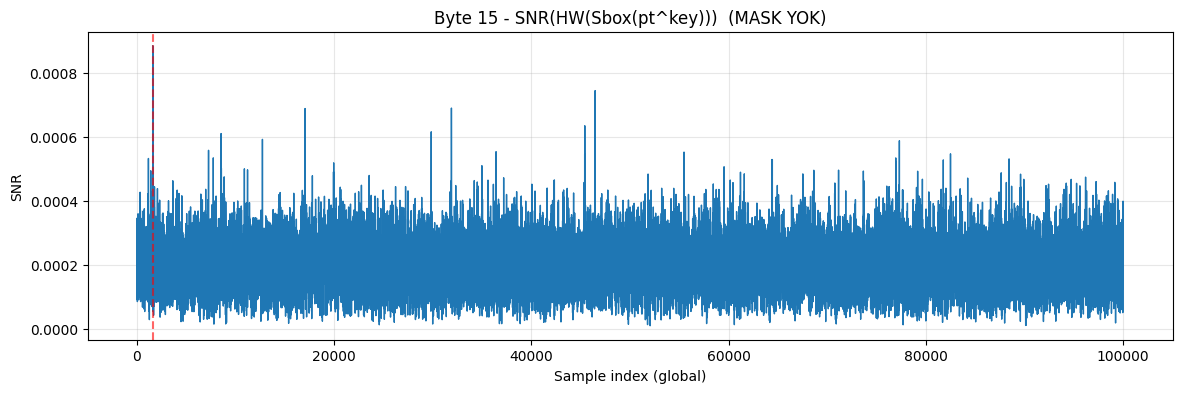

In [ ]:

import numpy as np
import h5py
import matplotlib.pyplot as plt

# =====================
# AYARLAR
# =====================
H5_PATH = "/content/drive/MyDrive/Methodology-for-efficient-CNN-architectures-in-SCA/ATMega8515_raw_traces.h5"
BYTE_IDX = 15

N_TRACES = 50000        # profiling tarafında kaç trace ile SNR hesaplayalım
TRACE_CHUNK = 2000      # RAM için parça parça oku

SAMPLE_START = 0
SAMPLE_END = None       # None => sona kadar
SAMPLE_STRIDE = 2       # 1 daha net ama daha yavaş; 2/5 genelde yeter

EPS = 1e-12

# =====================
# AES S-Box + HW
# =====================
AES_Sbox = np.array([
    0x63,0x7c,0x77,0x7b,0xf2,0x6b,0x6f,0xc5,0x30,0x01,0x67,0x2b,0xfe,0xd7,0xab,0x76,
    0xca,0x82,0xc9,0x7d,0xfa,0x59,0x47,0xf0,0xad,0xd4,0xa2,0xaf,0x9c,0xa4,0x72,0xc0,
    0xb7,0xfd,0x93,0x26,0x36,0x3f,0xf7,0xcc,0x34,0xa5,0xe5,0xf1,0x71,0xd8,0x31,0x15,
    0x04,0xc7,0x23,0xc3,0x18,0x96,0x05,0x9a,0x07,0x12,0x80,0xe2,0xeb,0x27,0xb2,0x75,
    0x09,0x83,0x2c,0x1a,0x1b,0x6e,0x5a,0xa0,0x52,0x3b,0xd6,0xb3,0x29,0xe3,0x2f,0x84,
    0x53,0xd1,0x00,0xed,0x20,0xfc,0xb1,0x5b,0x6a,0xcb,0xbe,0x39,0x4a,0x4c,0x58,0xcf,
    0xd0,0xef,0xaa,0xfb,0x43,0x4d,0x33,0x85,0x45,0xf9,0x02,0x7f,0x50,0x3c,0x9f,0xa8,
    0x51,0xa3,0x40,0x8f,0x92,0x9d,0x38,0xf5,0xbc,0xb6,0xda,0x21,0x10,0xff,0xf3,0xd2,
    0xcd,0x0c,0x13,0xec,0x5f,0x97,0x44,0x17,0xc4,0xa7,0x7e,0x3d,0x64,0x5d,0x19,0x73,
    0x60,0x81,0x4f,0xdc,0x22,0x2a,0x90,0x88,0x46,0xee,0xb8,0x14,0xde,0x5e,0x0b,0xdb,
    0xe0,0x32,0x3a,0x0a,0x49,0x06,0x24,0x5c,0xc2,0xd3,0xac,0x62,0x91,0x95,0xe4,0x79,
    0xe7,0xc8,0x37,0x6d,0x8d,0xd5,0x4e,0xa9,0x6c,0x56,0xf4,0xea,0x65,0x7a,0xae,0x08,
    0xba,0x78,0x25,0x2e,0x1c,0xa6,0xb4,0xc6,0xe8,0xdd,0x74,0x1f,0x4b,0xbd,0x8b,0x8a,
    0x70,0x3e,0xb5,0x66,0x48,0x03,0xf6,0x0e,0x61,0x35,0x57,0xb9,0x86,0xc1,0x1d,0x9e,
    0xe1,0xf8,0x98,0x11,0x69,0xd9,0x8e,0x94,0x9b,0x1e,0x87,0xe9,0xce,0x55,0x28,0xdf,
    0x8c,0xa1,0x89,0x0d,0xbf,0xe6,0x42,0x68,0x41,0x99,0x2d,0x0f,0xb0,0x54,0xbb,0x16
], dtype=np.uint8)

HW = np.array([bin(i).count("1") for i in range(256)], dtype=np.uint8)

def snr_hw_streaming(h5_path, byte_idx, n_traces, trace_chunk, sample_start, sample_end, sample_stride):
    with h5py.File(h5_path, "r") as f:
        traces_ds = f["traces"]
        md_ds = f["metadata"]

        total_traces, total_samples = traces_ds.shape
        n = min(int(n_traces), int(total_traces))

        s0 = int(sample_start)
        s1 = int(total_samples) if sample_end is None else int(sample_end)
        stride = int(sample_stride)

        T = len(range(s0, s1, stride))
        C = 9  # HW sınıfları 0..8

        counts = np.zeros(C, dtype=np.int64)
        sum_x = np.zeros((C, T), dtype=np.float64)
        sum_x2 = np.zeros((C, T), dtype=np.float64)

        # Profiling key byte (etiket için)
        key0 = md_ds[0]["key"].astype(np.uint8)
        real_k = int(key0[byte_idx])
        print("Profiling label için kullanılan gerçek key byte:", hex(real_k))

        for start in range(0, n, trace_chunk):
            end = min(n, start + trace_chunk)

            X = traces_ds[start:end, s0:s1:stride].astype(np.float32)   # (chunk, T)
            md = md_ds[start:end]
            pt = md["plaintext"].astype(np.uint8)
            key = md["key"].astype(np.uint8)

            # UNMASKED ara-değer: Sbox(pt^key)
            sbox_out = AES_Sbox[pt[:, byte_idx] ^ key[:, byte_idx]]
            labels = HW[sbox_out]  # 0..8

            for c in range(C):
                idx = (labels == c)
                if not np.any(idx):
                    continue
                Xc = X[idx]
                counts[c] += Xc.shape[0]
                sum_x[c] += Xc.sum(axis=0, dtype=np.float64)
                sum_x2[c] += (Xc * Xc).sum(axis=0, dtype=np.float64)

            if (start // trace_chunk) % 5 == 0:
                print(f"Processed {end}/{n} traces...")

        # SNR hesapla
        N = counts.sum()
        mean_all = sum_x.sum(axis=0) / max(N, 1)

        var_between = np.zeros(T, dtype=np.float64)
        var_within = np.zeros(T, dtype=np.float64)

        for c in range(C):
            if counts[c] < 2:
                continue
            pc = counts[c] / N
            mean_c = sum_x[c] / counts[c]
            var_c = (sum_x2[c] / counts[c]) - mean_c**2
            var_between += pc * (mean_c - mean_all) ** 2
            var_within += pc * var_c

        snr = (var_between / (var_within + EPS)).astype(np.float32)
        x_axis = np.arange(T) * stride + s0
        return snr, x_axis, real_k, counts

snr, x_axis, real_k, counts = snr_hw_streaming(
    H5_PATH, BYTE_IDX, N_TRACES, TRACE_CHUNK, SAMPLE_START, SAMPLE_END, SAMPLE_STRIDE
)

peak_i = int(np.argmax(snr))
print("\n=== UNMASKED-LABEL SNR SONUÇ ===")
print("Peak SNR:", float(snr[peak_i]), "at global sample:", int(x_axis[peak_i]))
print("HW class counts:", {i: int(c) for i, c in enumerate(counts)})

# Top 10 peak göster
topk = 10
top_idx = np.argsort(snr)[-topk:][::-1]
print("\nTop peaks (SNR, global_sample):")
for i in top_idx:
    print(" ", float(snr[i]), int(x_axis[i]))

plt.figure(figsize=(14,4))
plt.plot(x_axis, snr, linewidth=1)
plt.axvline(int(x_axis[peak_i]), color="r", linestyle="--", alpha=0.6)
plt.title(f"Byte {BYTE_IDX} - SNR(HW(Sbox(pt^key)))  (MASK YOK)")
plt.xlabel("Sample index (global)")
plt.ylabel("SNR")
plt.grid(True, alpha=0.3)
plt.show()